In [2]:
#!pip install --upgrade grpcio

In [2]:
#!conda install -c conda-forge optuna

^C


ESTAS PRUEBAS UTILIZAN PARTICIONAMIENTO ALEATORIO DE ENLACES A PARTIR DE UN SOLO ARCHIVO training_2018-2024.csv",
 Y DE AHI GENERA LOS SIGUIENTES:

train_data: contiene enlaces positivos y negativos para entrenamiento.

val_data: enlaces para validación (positivos y negativos generados automáticamente).

test_data: enlaces para prueba (positivos y negativos generados automáticamente).

4️⃣ Resumen del tipo de partición

Aleatorio a nivel de enlaces (Random Link Split)

Mantiene todos los nodos presentes

Genera enlaces negativos para balancear la clasificación de enlaces

Fracccionamiento configurable para validación y prueba

In [ ]:
UNA VEZ PARTICIONADOS LOS CONJUNTOS DE ENTRENAMIENTO, VALIDACION Y PRUEBAS, SE DIVIDEN EN FP, LSP Y GSP

Detalle de los componentes:
train_data.edge_index:

Contiene los índices de los nodos que están conectados en la red (los pares de nodos que forman las aristas).
Esta es una matriz de forma [2, num_aristas], donde cada columna representa una arista entre dos nodos.
train_data.edge_label_index:

Es un índice similar a edge_index, pero en el caso de la predicción de enlaces, generalmente es utilizado para indicar las aristas que se usan en la validación o prueba.
train_data.edge_label:

Contiene las etiquetas reales para la predicción de enlaces, típicamente 1 para indicar que hay una conexión entre los nodos y 0 para indicar que no hay conexión.
Estas son las etiquetas que quieres predecir.
¿Cómo encontrar la etiqueta (enlace)?
Cuando estás trabajando con link prediction, las etiquetas que necesitas comparar con tus predicciones están en train_data.edge_label (y en los conjuntos de prueba y validación también se encuentran en test_data.edge_label). Estas etiquetas te indican si existe o no una arista entre dos nodos en la red.

En resumen, no es train_data.edge_index ni train_data.edge_label_index las que contienen las etiquetas, sino que las etiquetas reales están en train_data.edge_label

In [12]:
#PROGRAMA 8-A ESTE PROGRAMA TOMA EL ARCHIVO Y PARTICIONA POR EDGES EN TRAIN, VAL Y TEST, TOMA LAS 14 METRICAS (FP+LSP+GSP)
# PROGRAMA 8A COMPLETO CON MODIFICACIONES SOLICITADAS
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import torch
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import random

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# =============================
# CARGA CSV Y FILTRADO
# =============================
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/training_2018-2024.csv",
}
df = pd.read_csv(file_paths["train_features"])

# Filtrar aristas conectadas
df = df[df['connected'] == 1].reset_index(drop=True)

# Reemplazar NaN en 'lenght_short_path' por mediana
df['lenght_short_path'] = df['lenght_short_path'].fillna(df['lenght_short_path'].median())

# Normalizar columnas numéricas
numeric_columns = [
    'sum_of_papers', 'sum_of_neighbors', 'log_secundary_neighbors', 'sum_of_keywords', 
    'keywords_match', 'sum_of_areas', 'lenght_short_path', 'clustering_index_sum', 
    'jaccard_coefficient', 'resource_allocation', 'adamic_adar_index', 'preferential_attachment', 
    'community_cn', 'community_ra'
]
scaler = MinMaxScaler()
df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

# =============================
# CONSTRUCCIÓN DEL GRAFO
# =============================
def build_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['sum_of_papers'], 
                row['sum_of_neighbors'], 
                row['log_secundary_neighbors'],
                row['sum_of_keywords'], 
                row['keywords_match'],
                row['sum_of_areas'], 
                row['lenght_short_path'],
                row['clustering_index_sum'],
                row['jaccard_coefficient'],
                row['resource_allocation'],
                row['adamic_adar_index'],
                row['preferential_attachment'],
                row['community_cn'],
                row['community_ra']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

G = build_graph(df)
G = add_node_features(G, df)

# =============================
# CONVERTIR A PyG
# =============================
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data = graph_to_pyg(G)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])
    data.edge_index = data.edge_index[:, sorted_indices]
    return data

# =============================
# SPLIT PYTORCH GEOMETRIC
# =============================
split = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0
)
train_data, val_data, test_data = split(data)
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)

# Guardar conjuntos en CSV
def save_edge_set_csv(data, filename, reverse_mapping):
    edge_list = [(reverse_mapping[u], reverse_mapping[v]) for u, v in data.edge_index.t().numpy()]
    df_edges = pd.DataFrame(edge_list, columns=["source", "target"])
    df_edges.to_csv(filename, index=False)

reverse_mapping = {v: k for k, v in data.node_mapping.items()}
save_edge_set_csv(train_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/train_edges_training_2018-2024.csv", reverse_mapping)
save_edge_set_csv(val_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/val_edges_training_2018-2024.csv", reverse_mapping)
save_edge_set_csv(test_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/test_edges_training_2018-2024.csv", reverse_mapping)

# =============================
# CALCULAR DENSIDADES
# =============================
def calc_density(G):
    if G.number_of_nodes() == 0:
        return 0
    return nx.density(G)

def density_for_dataset(data, description):
    nodes = [reverse_mapping[i] for i in range(data.num_nodes)]
    G_tmp = nx.Graph()
    for u, v in data.edge_index.t().numpy():
        G_tmp.add_edge(reverse_mapping[u], reverse_mapping[v])
    density = calc_density(G_tmp)
    print(f"Densidad {description}: {density:.4f}")
    return density

density_train = density_for_dataset(train_data, "Train")
density_val = density_for_dataset(val_data, "Validation")
density_test = density_for_dataset(test_data, "Test")

# =============================
# MODELOS GNN (mantener tu código original)
# =============================
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x
    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x
    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x
    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x
    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

# =============================
# FUNCIONES DE EVALUACIÓN Y ENTRENAMIENTO (mantener tu código original)
# =============================
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }


# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=14,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=14,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=14,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=14,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P8A-mejor_modelo_GCN.pth")
print("P8A-Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P8A-mejor_modelo_GAT.pth")
print("P8A-Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P8A-mejor_modelo_GIN.pth")
print("P8A-Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P8A-mejor_modelo_SAGE.pth")
print("P8A-Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P8A-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P8A-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P8A-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P8A-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 P8A-Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P8A-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P8A-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P8A-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P8A-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P8A-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P8A-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble
              


Densidad Train: 0.0151
Densidad Validation: 0.0151
Densidad Test: 0.0149
Best GCN hyperparameters: {'hidden_channels': 128, 'dropout_rate': 0.4961980867391592, 'learning_rate': 0.005121445644296433, 'weight_decay': 0.009939989447262803, 'epochs': 84}
Best GCN validation loss: 0.6263903379440308
Best GAT hyperparameters: {'hidden_channels': 43, 'heads': 3, 'dropout_rate': 0.0974314343086569, 'learning_rate': 0.00883065367094983, 'weight_decay': 0.0005178169234746678, 'epochs': 96}
Best GAT validation loss: 0.6139005422592163
Mejores parámetros para GCN: {'hidden_channels': 128, 'dropout_rate': 0.4961980867391592, 'learning_rate': 0.005121445644296433, 'weight_decay': 0.009939989447262803, 'epochs': 84}
Mejores parámetros para GIN: {'hidden_channels': 84, 'dropout_rate': 0.09546533138986957, 'learning_rate': 0.006718305600877424, 'weight_decay': 0.009175304010220257, 'epochs': 48}
Mejores parámetros para SAGE: {'hidden_channels': 35, 'num_layers': 3, 'dropout_rate': 0.18905972305191449, 

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:644: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:644: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:644: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.6071
Precision: 0.5833
Recall: 0.7500
F1 Score: 0.6562
AUC-ROC: 0.6071
Confusion Matrix:
[[13 15]
 [ 7 21]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:673: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:673: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\1780316718.py:673: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (SVC):
Accuracy: 0.7321
Precision: 0.7241
Recall: 0.7500
F1 Score: 0.7368
AUC-ROC: 0.7321
Confusion Matrix:
[[20  8]
 [ 7 21]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9643
Precision: 0.9643
Recall: 0.9643
F1 Score: 0.9643
AUC-ROC: 0.9643
Confusion Matrix:
[[27  1]
 [ 1 27]]



Esas cifras corresponden a la densidad de cada subgrafo que generaste (train, validation y test). Te explico con detalle:

1️⃣ Qué es la densidad de un grafo

La densidad mide qué tan conectado está un grafo, es decir, qué fracción de todas las posibles aristas existen realmente.

Para un grafo no dirigido con 
𝑁
N nodos:

Densidad
=
2
⋅
𝐸
𝑁
⋅
(
𝑁
−
1
)
Densidad=
N⋅(N−1)
2⋅E
	​


donde:

𝐸
E = número de aristas presentes

𝑁
N = número de nodos

El factor 2 es porque cada arista conecta dos nodos

La densidad siempre está entre 0 y 1:

0 → ningún nodo conectado

1 → todos los nodos conectados entre sí (grafo completo)

2️⃣ Interpretación de tus resultados

Densidad Train: 0.0151 → solo el 1.51 % de todas las posibles conexiones entre nodos están presentes en tu conjunto de entrenamiento.

Densidad Validation: 0.0151 → igual que el train, tu conjunto de validación tiene aproximadamente la misma proporción de conexiones.

Densidad Test: 0.0149 → muy similar, apenas un poco menos conectado.

Esto es normal en redes de tipo social o académico, donde la mayoría de pares de nodos no están conectados. Tu grafo es muy disperso (sparse).

3️⃣ Por qué es importante

Una densidad baja indica que el grafo es escasamente conectado, lo que puede afectar la predicción de enlaces:

Las heurísticas locales (como vecinos en común) pueden ser menos informativas.

Las GNNs pueden necesitar más capas o características para propagar información efectiva.

Que train, val y test tengan densidades similares es bueno, porque significa que los splits están equilibrados y comparables.

# CAMBIO DE DATOS DE ENTRADA! AHORA ESTADISTICAS SOBRE EL GRAFO

PROGRAMA 9
##### EL SIGUIENTE PROGRAMA USA 15 ESTADISTICAS SOBRE EL GRAFO DE LOS INVESTIGADORES DE LA UNAM DE 2018 A 2024 CON PARAMENTROS OPTIMZADO CON OPTUNA PARA ENTRENAR REDES NEURONALES GRAFICAS GCN, GIN, GAT Y SAGE
AQUI ORDENA LAS ARISTAS PARA LOS CUATRO MODELOS, SOBRETODO POR SAGE
Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)

camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'centralidad_cercanía_source', 'centralidad_cercanía_target',
                     'centralidad_intermediación_source', 'centralidad_intermediación_target',
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'centralidad_eigenvector_source', 'centralidad_eigenvector_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']
                     
CALCULADAS APARTE

EL RENDIMIENTO DE LAS REDES NEURONALES ES MENOR QUE POR HEURISTICA DE UNAM, PERO EL DEL METAMODEL ES MUCHO MEJOR!
- 
Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.512690   0.493671  0.410526  0.448276  0.516151  0.492807  1.533723
GAT   0.548223   0.554217  0.469388  0.508287  0.524428  0.550286  1.064203
GIN   0.517766   0.506667  0.395833  0.444444  0.507735  0.525065  1.117198
SAGE  0.482234   0.518182  0.537736  0.527778  0.515913  0.569936  0.815631

accuracy y precision GAT MEJOR
recall y f1 score SAGE MEJOR
AUC-ROC GAT mas grande
MSE GCN mayor y SAGE menor
SOBRE EL MODELO META CON REGRESIÓN LOGISTICA--ESTE SE COMPORTO MEJOR!
Métricas del modelo meta (Logistic Regression):
Accuracy: 0.7500
Precision: 0.7333
Recall: 0.7857
F1 Score: 0.7586
AUC-ROC: 0.7500
Confusion Matrix:
[[20  8]
 [ 6 22]]

RENDIMIENTTO DESPUES DE REDUCIR ALEATORIEDAD:
Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.517766   0.567164  0.365385  0.444444  0.499742  0.534077  1.506458
GAT   0.467005   0.478261  0.550000  0.511628  0.490464  0.513848  1.955614
GIN   0.472081   0.482759  0.135922  0.212121  0.493855  0.511347  2.247205
SAGE  0.492386   0.459770  0.430108  0.444444  0.490126  0.486848  1.513301

Métricas del modelo meta (Logistic Regression):
Accuracy: 0.5893
Precision: 0.5806
Recall: 0.6429
F1 Score: 0.6102
AUC-ROC: 0.5893
Confusion Matrix:
[[15 13]
 [10 18]]

SE REPITE LA EJECUCIÓN...Y SI ES REPRODUCIBLE

REINICIE EL KERNEL....Y SIGUE SIENDO REPRODUCIBLE

PRUEBA DE REEMPLAZO: Reemplazar NaN en 'lenght_short_path' por la mediana... SIGUE REPRODUCIBLE

IMPLEMENTANDO METAMODELOS

Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.517766   0.567164  0.365385  0.444444  0.499742  0.534077  1.506458
GAT   0.467005   0.478261  0.550000  0.511628  0.490464  0.513848  1.955614
GIN   0.472081   0.482759  0.135922  0.212121  0.493855  0.511347  2.247205
SAGE  0.492386   0.459770  0.430108  0.444444  0.490126  0.486848  1.513301

Primeras 20 predicciones GCN:
Gibrán Fuentes Pineda - Luis Alberto Pineda Cortés: 0.9612
Alfonso Gastélum Strozzi - Carlos Bruno Velarde Velázquez: 0.9373
Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5893
Precision: 0.5806
Recall: 0.6429
F1 Score: 0.6102
AUC-ROC: 0.5893
Confusion Matrix:
[[15 13]
 [10 18]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]
Métricas del modelo meta (SVC):
Accuracy: 0.7857
Precision: 0.7222
Recall: 0.9286
F1 Score: 0.8125
AUC-ROC: 0.7857
Confusion Matrix:
[[18 10]
 [ 2 26]]

Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9630
Recall: 0.9286
F1 Score: 0.9455
AUC-ROC: 0.9464
Confusion Matrix:
[[27  1]
 [ 2 26]]

Las densidades de los 15:estadisticas_autores2018-2024 es:
Densidad Train: 0.0151
Densidad Validation: 0.0151
Densidad Test: 0.0149

In [13]:
#PROGRAMA 9  15 ESTADISTICAS DE LA UNAM Y METAMODELOS
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	centralidad_cercanÃ­a_source	centralidad_cercanÃ­a_target	centralidad_intermediaciÃ³n_source	centralidad_intermediaciÃ³n_target	coeficiente_agrupamiento_source	coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target	


#REDUCIENDO ALEATORIEDAD

import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/15_estadisticas_autores_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
df_train['camino_más_corto'] = df_train['camino_más_corto'].fillna(df_train['camino_más_corto'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'centralidad_cercanía_source', 'centralidad_cercanía_target',
                     'centralidad_intermediación_source', 'centralidad_intermediación_target',
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'centralidad_eigenvector_source', 'centralidad_eigenvector_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	centralidad_cercanÃ­a_source	
#centralidad_cercanÃ­a_target	centralidad_intermediaciÃ³n_source	centralidad_intermediaciÃ³n_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['centralidad_cercanía_source'], 
                row['centralidad_cercanía_target'],
                row['centralidad_intermediación_source'], 
                row['centralidad_intermediación_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target'],
                row['centralidad_eigenvector_source'],
                row['centralidad_eigenvector_target'],
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Guardar conjuntos en CSV
def save_edge_set_csv(data, filename, reverse_mapping):
    edge_list = [(reverse_mapping[u], reverse_mapping[v]) for u, v in data.edge_index.t().numpy()]
    df_edges = pd.DataFrame(edge_list, columns=["source", "target"])
    df_edges.to_csv(filename, index=False)

reverse_mapping = {v: k for k, v in data.node_mapping.items()}
save_edge_set_csv(train_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/train_edges_15_autores-2018-2024.csv", reverse_mapping)
save_edge_set_csv(val_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/val_edges_15_autores-2018-2024.csv", reverse_mapping)
save_edge_set_csv(test_data, "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/test_edges_15_autores-2018-2024.csv", reverse_mapping)

# =============================
# CALCULAR DENSIDADES
# =============================
def calc_density(G):
    if G.number_of_nodes() == 0:
        return 0
    return nx.density(G)

def density_for_dataset(data, description):
    nodes = [reverse_mapping[i] for i in range(data.num_nodes)]
    G_tmp = nx.Graph()
    for u, v in data.edge_index.t().numpy():
        G_tmp.add_edge(reverse_mapping[u], reverse_mapping[v])
    density = calc_density(G_tmp)
    print(f"Densidad {description}: {density:.4f}")
    return density

density_train = density_for_dataset(train_data, "Train")
density_val = density_for_dataset(val_data, "Validation")
density_test = density_for_dataset(test_data, "Test")



# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=15,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=15,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=15,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=15,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P9-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P9-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P9-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P9-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P9-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P9-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P9-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P9-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P9-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P9-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P9-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P9-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P9-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P9-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble




Densidad Train: 0.0151
Densidad Validation: 0.0151
Densidad Test: 0.0149
Best GCN hyperparameters: {'hidden_channels': 43, 'dropout_rate': 0.2640761469386411, 'learning_rate': 0.004854446618752362, 'weight_decay': 0.0051981099662155045, 'epochs': 55}
Best GCN validation loss: 0.6607860922813416
Best GAT hyperparameters: {'hidden_channels': 113, 'heads': 5, 'dropout_rate': 0.06898141191112013, 'learning_rate': 0.009232622323780495, 'weight_decay': 0.0005374325346507193, 'epochs': 93}
Best GAT validation loss: 0.5546630620956421
Mejores parámetros para GCN: {'hidden_channels': 43, 'dropout_rate': 0.2640761469386411, 'learning_rate': 0.004854446618752362, 'weight_decay': 0.0051981099662155045, 'epochs': 55}
Mejores parámetros para GIN: {'hidden_channels': 65, 'dropout_rate': 0.1865106974156902, 'learning_rate': 0.0058776997933080635, 'weight_decay': 0.001009313441190641, 'epochs': 77}
Mejores parámetros para SAGE: {'hidden_channels': 52, 'num_layers': 3, 'dropout_rate': 0.3041132297615244

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:677: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:677: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:677: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5893
Precision: 0.5806
Recall: 0.6429
F1 Score: 0.6102
AUC-ROC: 0.5893
Confusion Matrix:
[[15 13]
 [10 18]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:706: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:706: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_8748\2247097400.py:706: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (SVC):
Accuracy: 0.7857
Precision: 0.7222
Recall: 0.9286
F1 Score: 0.8125
AUC-ROC: 0.7857
Confusion Matrix:
[[18 10]
 [ 2 26]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9630
Recall: 0.9286
F1 Score: 0.9455
AUC-ROC: 0.9464
Confusion Matrix:
[[27  1]
 [ 2 26]]



PROGRAMA 10
EL SIGUIENTE PROGRAMA USA SOLO 9 ESTADISTICAS SOBRE EL GRAFO DE LOS INVESTIGADORES DE LA UNAM DE 2018 A 2024 CON PARAMENTROS OPTIMZADO CON OPTUNA 
PARA ENTRENAR REDES NEURONALES GRAFICAS GCN, GIN, GAT Y SAGE  Y METAMODELOS
= [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']
    
EL RENDIMIENTO NO ES MEJOR QUE CON LAS 15 ESTADÍSTICAS, NI LAS REDES NI EL METAMODEL
-

    Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.461929   1.000000  0.000000  0.000000  0.493521  0.520094  1.447781
GAT   0.467005   0.469388  0.989247  0.636678  0.489506  0.472974  0.279683
GIN   0.527919   0.510417  0.515789  0.513089  0.523478  0.513651  4.244338
SAGE  0.507614   0.428571  0.031250  0.058252  0.539707  0.507328  1.217461

accuracy GIN mejor
Precision GCN mejor
Recall GAT mejor
F1score GAT mejor
AUC-ROC SAGE mayor, GAT menor
AUC-PR GCN mahyor, GAT menor
MSE GIN GAT menor

Métricas del modelo meta (Logistic Regression):
Accuracy: 0.5357  MEJOR
Precision: 0.5417
Recall: 0.4643
F1 Score: 0.5000
AUC-ROC: 0.5357
Confusion Matrix:
[[17 11]
 [15 13]]

 REDUCIENDO ALEATORIEDAD:

 Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.609137   0.560606  0.435294  0.490066  0.611870  0.505611  1.228281
GAT   0.517766   0.522727  0.464646  0.491979  0.562358  0.597564  1.677470
GIN   0.507614   0.523256  0.445545  0.481283  0.484323  0.488655  1.671981
SAGE  0.507614   0.493827  0.416667  0.451977  0.506240  0.489857  1.640332

Primeras 20 predicciones GCN:
Alfonso Gastélum Strozzi - Carlos Bruno Velarde Velázquez: 0.9386

Métricas del modelo meta (Logistic Regression):  ESTE METAMODELO ESTA MUCHO MEJOR!
Accuracy: 0.6607
Precision: 0.6957
Recall: 0.5714
F1 Score: 0.6275
AUC-ROC: 0.6607
Confusion Matrix:
[[21  7]
 [12 16]]

 AHORA # Reemplazar NaN en 'lenght_short_path' por la mediana no cambio significa que no hay nan

 Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.609137   0.560606  0.435294  0.490066  0.611870  0.505611  1.228281
GAT   0.517766   0.522727  0.464646  0.491979  0.562358  0.597564  1.677470
GIN   0.507614   0.523256  0.445545  0.481283  0.484323  0.488655  1.671981
SAGE  0.507614   0.493827  0.416667  0.451977  0.506240  0.489857  1.640332

Métricas del modelo meta (Logistic Regression):
Accuracy: 0.6607
Precision: 0.6957
Recall: 0.5714
F1 Score: 0.6275
AUC-ROC: 0.6607
Confusion Matrix:
[[21  7]
 [12 16]]

IMPLEMENTANDO METAMODELOS

 Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.609137   0.560606  0.435294  0.490066  0.611870  0.505611  1.228281
GAT   0.517766   0.522727  0.464646  0.491979  0.562358  0.597564  1.677470
GIN   0.507614   0.523256  0.445545  0.481283  0.484323  0.488655  1.671981
SAGE  0.507614   0.493827  0.416667  0.451977  0.506240  0.489857  1.640332

Primeras 20 predicciones GCN:
Alfonso Gastélum Strozzi - Carlos Bruno Velarde Velázquez: 0.9386
Gibrán Fuentes Pineda - Luis Alberto Pineda Cortés: 0.9106
Métricas del modelo meta (LogisticRegression):
Accuracy: 0.6607
Precision: 0.6957
Recall: 0.5714
F1 Score: 0.6275
AUC-ROC: 0.6607
Confusion Matrix:
[[21  7]
 [12 16]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando SVC...
Métricas del modelo meta (SVC):
Accuracy: 0.6786
Precision: 0.7778
Recall: 0.5000
F1 Score: 0.6087
AUC-ROC: 0.6786
Confusion Matrix:
[[24  4]
 [14 14]]
Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9032
Recall: 1.0000
F1 Score: 0.9492
AUC-ROC: 0.9464
Confusion Matrix:
[[25  3]
 [ 0 28]]

PROGRAMA 1O SE CORRE CON DATOS UNAM CON 9 ESTADÍSTICAS (EL PROGRAMA DE ARRIBA USA 15 ESTADÍSTICAS, PERO EL ARCHIVO ES PEQUEÑO EN AMBOS CASOS IMPLEMENTANDO METAMODELOS

In [1]:
#PROGRAMA 10  9 ESTADISTICAS CON UNAM Y METAMODELOS
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F

#REDUCIENDO ALEATORIEDAD
import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target, coeficiente_agrupamiento_source	coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target	

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_2018-2024.csv",
    #"train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_1993-2003-final.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
df_train['camino_más_corto'] = df_train['camino_más_corto'].fillna(df_train['camino_más_corto'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target'],
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=9,  # Número de características de entrada, antes 15 estadisticas, ahora 9
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=9,  # Ajusta según tu modelo al numero de caracteristicas de entrada (estadisticas,no los campos)
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar  #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P10-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble




Best GCN hyperparameters: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Best GCN validation loss: 0.673192024230957
Best GAT hyperparameters: {'hidden_channels': 82, 'heads': 6, 'dropout_rate': 0.05551438385281513, 'learning_rate': 0.008619470934343806, 'weight_decay': 3.715491859582719e-05, 'epochs': 92}
Best GAT validation loss: 0.5486426949501038
Mejores parámetros para GCN: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Mejores parámetros para GIN: {'hidden_channels': 53, 'dropout_rate': 0.14151681758586332, 'learning_rate': 0.0019441944472424217, 'weight_decay': 0.0031779336001614405, 'epochs': 53}
Mejores parámetros para SAGE: {'hidden_channels': 29, 'num_layers': 2, 'dropout_rate': 0.07814354250454825, 'learning_rate': 0.006671505252115448, 'weight_decay': 0.0094286566710

C:\Users\pilarang\AppData\Local\Temp\ipykernel_7864\4059436401.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn_model.load_state_dict(torch.load("mejor_modelo_GCN.p

Optimizando LogisticRegression...


C:\Users\pilarang\AppData\Local\Temp\ipykernel_7864\4059436401.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7864\4059436401.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7864\4059436401.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Te


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.6607
Precision: 0.6957
Recall: 0.5714
F1 Score: 0.6275
AUC-ROC: 0.6607
Confusion Matrix:
[[21  7]
 [12 16]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando SVC...


...


Métricas del modelo meta (SVC):
Accuracy: 0.6786
Precision: 0.7778
Recall: 0.5000
F1 Score: 0.6087
AUC-ROC: 0.6786
Confusion Matrix:
[[24  4]
 [14 14]]

Optimizando XGBoost...


C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:12:58] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:12:58] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:12:58] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:12:58] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pil


Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9032
Recall: 1.0000
F1 Score: 0.9492
AUC-ROC: 0.9464
Confusion Matrix:
[[25  3]
 [ 0 28]]



C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [17:13:03] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


'\n## ensamble de aqui hacia arriba ya no cambiar #\nfrom sklearn.linear_model import LogisticRegression\n# Obtener las predicciones de los modelos\n\ntrue_labels = test_data.edge_label.numpy()\n# Verifica la longitud de las etiquetas y las predicciones\n#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones\n# Debe ser el mismo tamaño que las etiquetas\n\npredicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()\n#print("Número de predicciones de gcn",len(predicciones_gcn))  \n\npredicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()\n#print("Número de predicciones de gat",len(predicciones_gat))  \n\npredicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()\n#print("Número de predicciones de gin",len(predicciones_gin))  \n\npredicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu

PROGRAAMA 11 SE CORRE CON   REGISTROS Y 9 ESTADÍSTICAS DE REDES DE AUTORES DE STANDFORD, PARA COMPARAR EL RENDIMIENTO DE LAS 
REDES NEURONALES GRAFICAS  CON RESPECTO AL TAMAÑO DE LOS DATOS

PROGRAMA 11
EL SIGUIENTE PROGRAMA USA SOLO 9 ESTADISTICAS SOBRE EL GRAFO DE LOS INVESTIGADORES DE OXFORD DE 1993 A 2003 CON PARAMENTROS OPTIMZADO CON OPTUNA 
PARA ENTRENAR REDES NEURONALES GRAFICAS GCN, GIN, GAT Y SAGE
# SIN Reemplazar NaN en 'lenght_short_path' por la mediana
= [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']
EL RENDIMIENTO:
Métricas comparativas de GCN, GAT, GIN y SAGE: DE LOS INVESTIGADORES DE OXFORD CON MAS DATOS
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR         MSE
GCN   0.502877   0.495533  0.334843  0.399640  0.499842  0.492967    1.483019
GAT   0.495792   0.502057  0.564623  0.531505  0.495615  0.504682    1.017421
GIN   0.504475   0.515299  0.079285  0.137426  0.502434  0.499097  227.368165
SAGE  0.496644   0.491150  0.344905  0.405237  0.495281  0.493572    1.497632

accuracy GIN mejor
precision GIN mejor
recall GIN mejor
f1 score GAT mejor
AUC ROC Gin mayor SAGE menor
AUCPR GAT mayor GCN menor
MSE GIN muy muy alto, GAT 1.01

Métricas del modelo meta (Logistic Regression):
Accuracy: 0.5456
Precision: 0.5357
Recall: 0.6844
F1 Score: 0.6010
AUC-ROC: 0.5456
Confusion Matrix:
[[ 8059 11752]
 [ 6253 13558]]

COMPARANDO CON LOS DATOS DE LA UNAM QUE SON MUCHO MENOS... EL RENDIMIENTO CUANDO SON MAS DATOS ES MEJOR EN TODAS LAS REDES NEURONALES Y EN EL METAMODEL.
-
    
    Métricas comparativas de GCN, GAT, GIN y SAGE: POCOS DATOS UNAM
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR       MSE
GCN   0.461929   1.000000  0.000000  0.000000  0.493521  0.520094  1.447781
GAT   0.467005   0.469388  0.989247  0.636678  0.489506  0.472974  0.279683
GIN   0.527919   0.510417  0.515789  0.513089  0.523478  0.513651  4.244338
SAGE  0.507614   0.428571  0.031250  0.058252  0.539707  0.507328  1.217461

accuracy GIN mejor
Precision GCN mejor
Recall GAT mejor
F1score GAT mejor
AUC-ROC SAGE mayor, GAT menor
AUC-PR GCN mahyor, GAT menor
MSE GIN GAT menor

Métricas del modelo meta (Logistic Regression):
Accuracy: 0.5357  MEJOR
Precision: 0.5417
Recall: 0.4643
F1 Score: 0.5000
AUC-ROC: 0.5357
Confusion Matrix:
[[17 11]
 [15 13]]


 REDUCIENDO ALEATORIEDAD--QUEDA PENDIENTE LA EJECUCIÓN PORQUE TARDA MUCHO PARA OXFORD

 IMPLEMENTANDO METAMODELOS

 

In [1]:
#PROGRAMA 11 EJECUCION CON VALORES STANDFOR Y 9 ESTADISTICAS Y METAMODELOS
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target, coeficiente_agrupamiento_source	coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target	

#REDUCIENDO ALEATORIEDAD
import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    #"train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_2018-2024.csv",
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_1993-2003-final.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target'],
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

train_data = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)


# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(train_data)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=9,  # Número de características de entrada, antes 15 estadisticas, ahora 9
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=9,  # Ajusta según tu modelo al numero de caracteristicas de entrada (estadisticas,no los campos)
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P11-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P11-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P11-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P11-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P11-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P11-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P11-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P11-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P11-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P11-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P11-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P11-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P11-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)

## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P11-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble




Best GCN hyperparameters: {'hidden_channels': 95, 'dropout_rate': 0.3120231955394348, 'learning_rate': 0.0076935277145935566, 'weight_decay': 0.00020210645359197452, 'epochs': 92}
Best GCN validation loss: 0.5441283583641052
Best GAT hyperparameters: {'hidden_channels': 55, 'heads': 5, 'dropout_rate': 0.11812877552267362, 'learning_rate': 0.009969555654857512, 'weight_decay': 2.5405937641415294e-05, 'epochs': 100}
Best GAT validation loss: 0.5681757926940918
Mejores parámetros para GCN: {'hidden_channels': 95, 'dropout_rate': 0.3120231955394348, 'learning_rate': 0.0076935277145935566, 'weight_decay': 0.00020210645359197452, 'epochs': 92}
Mejores parámetros para GIN: {'hidden_channels': 25, 'dropout_rate': 0.06311197235320248, 'learning_rate': 0.0032966261469881716, 'weight_decay': 0.006432843651925738, 'epochs': 100}
Mejores parámetros para SAGE: {'hidden_channels': 52, 'num_layers': 3, 'dropout_rate': 0.3041132297615244, 'learning_rate': 0.007311719225115481, 'weight_decay': 0.0042233

C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn_model.load_state_dict(torch.load("P11-mejor_modelo_GC


📊 Métricas comparativas de GCN, GAT, GIN y SAGE:
      Accuracy  Precision    Recall  F1 Score   AUC-ROC    AUC-PR        MSE
GCN   0.501278   0.503332  0.345348  0.409636  0.502219  0.504279   1.492138
GAT   0.498242   0.500000  0.395159  0.441440  0.499042  0.501705   1.548586
GIN   0.498668   0.502592  0.226121  0.311911  0.493693  0.501871  93.340971
SAGE  0.498722   0.497576  0.559248  0.526612  0.498230  0.497668   0.969946

Primeras 20 predicciones GCN:
111161.0 - 93504.0: 1.0000
53213.0 - 44612.0: 1.0000
92790.0 - 62821.0: 1.0000
44612.0 - 62821.0: 1.0000
21718.0 - 90402.0: 1.0000
28516.0 - 53213.0: 1.0000
111161.0 - 89732.0: 1.0000
90402.0 - 89732.0: 1.0000
38966.0 - 53213.0: 1.0000
93504.0 - 75223.0: 1.0000
92790.0 - 75223.0: 1.0000
35290.0 - 52682.0: 1.0000
53213.0 - 117350.0: 1.0000
18314.0 - 44612.0: 1.0000
47968.0 - 89732.0: 1.0000
50808.0 - 62821.0: 1.0000
21718.0 - 49118.0: 1.0000
94235.0 - 90402.0: 1.0000
89732.0 - 75223.0: 1.0000
97249.0 - 93504.0: 1.0000

Primeras 2

C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:632: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:632: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:632: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5455
Precision: 0.5360
Recall: 0.6781
F1 Score: 0.5987
AUC-ROC: 0.5455
Confusion Matrix:
[[ 8180 11631]
 [ 6377 13434]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 0.7856
Precision: 0.7485
Recall: 0.8603
F1 Score: 0.8005
AUC-ROC: 0.7856
Confusion Matrix:
[[14083  5728]
 [ 2767 17044]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 0.8490
Precision: 0.8274
Recall: 0.8819
F1 Score: 0.8538
AUC-ROC: 0.8490
Confusion Matrix:
[[16167  3644]
 [ 2339 17472]]

Optimizando SVC...


C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:661: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:661: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_2868\572346378.py:661: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\


Métricas del modelo meta (SVC):
Accuracy: 0.5773
Precision: 0.5663
Recall: 0.6600
F1 Score: 0.6096
AUC-ROC: 0.5773
Confusion Matrix:
[[ 9799 10012]
 [ 6736 13075]]

Optimizando XGBoost...


C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:35:54] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:35:54] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:35:54] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pilarang\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [07:35:55] WARNING: D:\bld\xgboost-split_1737531311373\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\pil


Métricas del modelo meta (XGBoost):
Accuracy: 0.5879
Precision: 0.5766
Recall: 0.6620
F1 Score: 0.6163
AUC-ROC: 0.5879
Confusion Matrix:
[[10180  9631]
 [ 6696 13115]]



In [30]:
PROGRAMA 12 9 estadisticas con UNAM  LSP+GSP

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target, coeficiente_agrupamiento_source	coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target	

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_2018-2024.csv",
    #"train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_1993-2003-final.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto', 
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target'],
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

train_data = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)


# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(train_data)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=9,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=9,  # Número de características de entrada, antes 15 estadisticas, ahora 9
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=9,  # Ajusta según tu modelo al numero de caracteristicas de entrada (estadisticas,no los campos)
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
#print("Número de predicciones de sage",len(predicciones_sage))  

X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix


# Ensamble de aquí hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Obtener las predicciones de los modelos
true_labels = test_data.edge_label.numpy()

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()

X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model
def objective_meta(trial):
    # Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
    X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))
  
    # Configura el modelo meta (regresión logística, por ejemplo)
    meta_model = LogisticRegression(C=trial.suggest_loguniform('C', 1e-5, 1e5), 
                                    max_iter=trial.suggest_int('max_iter', 100, 1000))

    # Entrena el modelo meta usando las predicciones base y las etiquetas verdaderas
    meta_model.fit(X_stack, true_labels)

    predicciones_finales = meta_model.predict(X_stack)
    
    # Calcula la métrica para evaluar el rendimiento del modelo meta (como AUC, F1, etc.)
    val_score = roc_auc_score(true_labels, predicciones_finales)

    return val_score

#study = optuna.create_study(direction='maximize')  # Si estás maximizando una métrica como AUC
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))

study.optimize(objective_meta, n_trials=50)

# Obtener los mejores hiperparámetros encontrados por Optuna
best_params = study.best_params
print(f"Mejores hiperparámetros: {best_params}")

# Crear el modelo meta con los mejores hiperparámetros
meta_model = LogisticRegression(C=best_params['C'], max_iter=best_params['max_iter'])

# Entrenar el modelo meta con los datos de entrenamiento
meta_model.fit(X_stack, true_labels)

### FIN Optimizar con OPtuna modelo ensamble

# Usar un modelo de regresión logística como modelo meta directo, sin optimizar
# Concatenar las predicciones de todos los modelos para crear el conjunto de datos para el modelo meta
#X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))
#meta_model = LogisticRegression()
#meta_model.fit(X_stack, true_labels)  # true_labels son las etiquetas reales de los datos de prueba

# Hacer las predicciones finales con el modelo meta
predicciones_finales = meta_model.predict(X_stack)
predicciones_autores = []
for i, (author1_idx, author2_idx) in enumerate(test_pairs):
    # Convertir los índices de los autores a sus nombres usando reverse_mapping
    author1_name = reverse_mapping[author1_idx]
    author2_name = reverse_mapping[author2_idx]
    score = predicciones_finales[i]  # 1 o 0 (indica si hay enlace o no)
    predicciones_autores.append((author1_name, author2_name, score))

# Imprimir las primeras 20 predicciones
print("\nPrimeras 20 predicciones del modelo meta (Logistic Regression):")
for author1, author2, score in predicciones_autores[:20]:
    print(f"{author1} - {author2}: {score}")
    
# Guardar las predicciones en un CSV si es necesario
import pandas as pd
df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
df.to_csv("predicciones_meta.csv", index=False)

# Calcular las métricas para el modelo meta
accuracy = accuracy_score(true_labels, predicciones_finales)
precision = precision_score(true_labels, predicciones_finales)
recall = recall_score(true_labels, predicciones_finales)
f1 = f1_score(true_labels, predicciones_finales)
roc_auc = roc_auc_score(true_labels, predicciones_finales)
conf_matrix = confusion_matrix(true_labels, predicciones_finales)

# Mostrar los resultados
print("Métricas del modelo meta (Logistic Regression):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")

# Modelos meta alternativos (Redes Neuronales y más complejos)

# Definir una red neuronal simple para el modelo meta
class MetaModelNN(nn.Module):
    def __init__(self, input_dim):
        super(MetaModelNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return self.sigmoid(x)

# Función objetivo para optimizar con Optuna
def objective_meta_nn(trial):
    # Configurar el modelo de red neuronal
    model = MetaModelNN(input_dim=4)
    optimizer = torch.optim.Adam(model.parameters(), lr=trial.suggest_loguniform('lr', 1e-5, 1e-1))
    criterion = nn.BCELoss()

    # Convertir las predicciones a tensores de PyTorch
    X_tensor = torch.tensor(X_stack, dtype=torch.float32)
    y_tensor = torch.tensor(true_labels, dtype=torch.float32)

    # Entrenar el modelo
    model.train()
    for epoch in range(100):  # Número de épocas
        optimizer.zero_grad()
        outputs = model(X_tensor).squeeze()
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    # Hacer predicciones y evaluar el rendimiento
    model.eval()
    with torch.no_grad():
        predicciones_finales = model(X_tensor).squeeze().numpy()
        predicciones_finales = (predicciones_finales > 0.5).astype(int)
    
    val_score = roc_auc_score(true_labels, predicciones_finales)
    return val_score

#study_nn = optuna.create_study(direction='maximize')
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_nn.optimize(objective_meta_nn, n_trials=50)

# Obtener los mejores hiperparámetros para el modelo de red neuronal
best_params_nn = study_nn.best_params
print(f"Mejores hiperparámetros para la red neuronal meta: {best_params_nn}")

# Crear el modelo de red neuronal meta con los mejores hiperparámetros
meta_nn_model = MetaModelNN(input_dim=4)
optimizer_nn = torch.optim.Adam(meta_nn_model.parameters(), lr=best_params_nn['lr'])
criterion = nn.BCELoss()

# Convertir las predicciones a tensores de PyTorch
X_tensor = torch.tensor(X_stack, dtype=torch.float32)
y_tensor = torch.tensor(true_labels, dtype=torch.float32)

# Entrenar el modelo
meta_nn_model.train()
for epoch in range(100):  # Número de épocas
    optimizer_nn.zero_grad()
    outputs = meta_nn_model(X_tensor).squeeze()
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer_nn.step()

# Hacer las predicciones finales con el modelo de red neuronal
meta_nn_model.eval()
with torch.no_grad():
    predicciones_finales_nn = meta_nn_model(X_tensor).squeeze().numpy()
    predicciones_finales_nn = (predicciones_finales_nn > 0.5).astype(int)

# Evaluar el rendimiento del modelo de red neuronal
accuracy_nn = accuracy_score(true_labels, predicciones_finales_nn)
precision_nn = precision_score(true_labels, predicciones_finales_nn)
recall_nn = recall_score(true_labels, predicciones_finales_nn)
f1_nn = f1_score(true_labels, predicciones_finales_nn)
roc_auc_nn = roc_auc_score(true_labels, predicciones_finales_nn)
conf_matrix_nn = confusion_matrix(true_labels, predicciones_finales_nn)

# Mostrar los resultados de la red neuronal
print("Métricas del modelo meta (Red Neuronal):")
print(f"Accuracy: {accuracy_nn:.4f}")
print(f"Precision: {precision_nn:.4f}")
print(f"Recall: {recall_nn:.4f}")
print(f"F1 Score: {f1_nn:.4f}")
print(f"AUC-ROC: {roc_auc_nn:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_nn}")

# Calcular las métricas para el modelo meta
accuracy = accuracy_score(true_labels, predicciones_finales)
precision = precision_score(true_labels, predicciones_finales)
recall = recall_score(true_labels, predicciones_finales)
f1 = f1_score(true_labels, predicciones_finales)
roc_auc = roc_auc_score(true_labels, predicciones_finales)
conf_matrix = confusion_matrix(true_labels, predicciones_finales)

# Mostrar los resultados
print("Métricas del modelo meta (Logistic Regression):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {roc_auc:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")


Best GCN hyperparameters: {'hidden_channels': 46, 'dropout_rate': 0.09348775692218547, 'learning_rate': 0.0010229731362892695, 'weight_decay': 0.0054130136390143115, 'epochs': 78}
Best GCN validation loss: 0.6576804518699646
Best GAT hyperparameters: {'hidden_channels': 110, 'heads': 2, 'dropout_rate': 0.13866404403091842, 'learning_rate': 0.0027821008918010115, 'weight_decay': 0.008050684479015063, 'epochs': 23}
Best GAT validation loss: 0.6826854348182678
Mejores parámetros para GCN: {'hidden_channels': 46, 'dropout_rate': 0.09348775692218547, 'learning_rate': 0.0010229731362892695, 'weight_decay': 0.0054130136390143115, 'epochs': 78}
Mejores parámetros para GIN: {'hidden_channels': 69, 'dropout_rate': 0.10355184482010199, 'learning_rate': 0.005556131593307134, 'weight_decay': 0.008093690668989868, 'epochs': 94}
Mejores parámetros para SAGE: {'hidden_channels': 17, 'num_layers': 4, 'dropout_rate': 0.35306095922433695, 'learning_rate': 0.0004684730830520765, 'weight_decay': 0.00075161

C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:451: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn_model.load_state_dict(torch.load("mejor_modelo_GCN.p


Primeras 20 predicciones GAT:
Alfonso Gastélum Strozzi - Fabián Torres Robles: 0.7401
Gabriel Ascanio Gasca - Alfonso Gastélum Strozzi: 0.7083
Ernesto Bribiesca Correa - Nidiyare Hevia Montiel: 0.6689
Sofía Natalia Galicia Haro - Edgar Garduño Angeles: 0.6466
Jorge Pérez González - Christopher David Wood: 0.6466
Luis Alberto Pineda Cortés - Mauricio Reyes Ruiz: 0.6327
Wendy Elizabeth Aguilar Martínez - Carlos Bruno Velarde Velázquez: 0.6280
Graciela Velasco Herrera - Tetyana Baydyk: 0.6231
Wendy Elizabeth Aguilar Martínez - Enrique Galindo Fentanes: 0.6198
David Arturo Rosenblueth Laguette - Luis Alberto Pineda Cortés: 0.6190
Gabriel Isaac Corkidi Blanco - Adan Oswaldo Guerrero Cárdenas: 0.6142
Enrique Galindo Fentanes - Gabriel Isaac Corkidi Blanco: 0.6111
Fernando Arámbula Cosío - T. Capistrán: 0.5998
Miguel Ángel Padilla Castañeda - Francisco Hernández Quiroz: 0.5979
Carlos Francisco Méndez Cruz - Gerardo Eugenio Sierra Martínez: 0.5944
Leticia Vega Alvarado - Ismael Herrera Revill

C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:592: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  meta_model = LogisticRegression(C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:592: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  meta_model = LogisticRegression(C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:592: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  meta_model = L

Mejores hiperparámetros: {'C': 0.02278401489742103, 'max_iter': 232}

Primeras 20 predicciones del modelo meta (Logistic Regression):
Ernesto José María De La Salete Belmont Moreno - T. Capistrán: 1.0
Tom Froese - Ruben Yvan Maarten Fossion: 1.0
Maria Elena Alvarez Buylla Roces - Pedro Arturo Góngora Luna: 0.0
Javier Gómez Castellanos - Victor Manuel Lomas Barrie: 0.0
Graciela Velasco Herrera - Tetyana Baydyk: 1.0
Maria Elena Alvarez Buylla Roces - Luis Antonio Mendoza Sierra: 0.0
Carlos Francisco Méndez Cruz - Gerardo Eugenio Sierra Martínez: 1.0
A. Sandoval - C. Espinoza: 0.0
Jesús Savage Carmona - Oscar Fuentes Casarrubias: 0.0
Arturo Iriarte Valverde - Alejandro Lara Sánchez: 0.0
Héctor Benítez Pérez - Julio Solano González: 0.0
Wendy Elizabeth Aguilar Martínez - Carlos Bruno Velarde Velázquez: 1.0
Gerardo Hernández Chavez - Víctor Lomas Barrie: 0.0
Ernesto José María De La Salete Belmont Moreno - Demetrio Fabián García Nocetti: 1.0
J. Perez Gonzalez - Nidiyare  Hevia Montiel: 0.0


C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:684: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  optimizer = torch.optim.Adam(model.parameters(), lr=trial.suggest_loguniform('lr', 1e-5, 1e-1))
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:684: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  optimizer = torch.optim.Adam(model.parameters(), lr=trial.suggest_loguniform('lr', 1e-5, 1e-1))
C:\Users\pilarang\AppData\Local\Temp\ipykernel_7180\1312377383.py:684: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(

Mejores hiperparámetros para la red neuronal meta: {'lr': 0.0036361642485956713}
Métricas del modelo meta (Red Neuronal):
Accuracy: 0.5357
Precision: 0.5385
Recall: 0.5000
F1 Score: 0.5185
AUC-ROC: 0.5357
Confusion Matrix:
[[16 12]
 [14 14]]
Métricas del modelo meta (Logistic Regression):
Accuracy: 0.5357
Precision: 0.5385
Recall: 0.5000
F1 Score: 0.5185
AUC-ROC: 0.5357
Confusion Matrix:
[[16 12]
 [14 14]]


In [ ]:
EL SIGUIENTE PROGRAMA 13 EXPERIMENTA CON LA EFECTIVIDAD DE GNN CON LOCAL STRUCTURAL PROXIMITY LSP Y GNN Y METAMODELOS

In [27]:
#PROGRAMA 13  ESTADISTICAS LOCAL STRUCTURAL PROXIMITY LA UNAM Y METAMODELOS DE LAS METRICAS LSP con training y con estadisticas_autores_2018-20-24
# 'centralidad_grado_source', 'centralidad_grado_target', 'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F

#REDUCIENDO ALEATORIEDAD

import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/LSP_estadisticas_autores_2018-2024.csv",
   
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['camino_más_corto'] = df_train['camino_más_corto'].fillna(df_train['camino_más_corto'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target',
                    ]

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)

# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.5),
        "Precision": precision_score(y_true, y_pred > 0.5, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.5),
        "F1 Score": f1_score(y_true, y_pred > 0.5),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=4,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P13-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P13-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P13-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P13-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P13-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P13-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P13-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P13-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P13-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P13-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P13-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P13-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P13-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos


true_labels = test_data.edge_label.cpu().numpy()
print("Valores únicos en true_labels:", np.unique(true_labels))

# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print("shape predicciones de gcn",true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print("shape predicciones de gat",true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print("shape predicciones de gin",true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print("shape predicciones de sage",true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P13-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble




Best GCN hyperparameters: {'hidden_channels': 35, 'dropout_rate': 0.3869588325178902, 'learning_rate': 0.0037897739178609927, 'weight_decay': 0.008193867799977404, 'epochs': 95}
Best GCN validation loss: 0.6787935495376587
Best GAT hyperparameters: {'hidden_channels': 43, 'heads': 8, 'dropout_rate': 0.49874536142660364, 'learning_rate': 0.004941603973128323, 'weight_decay': 0.00046706296231483667, 'epochs': 48}
Best GAT validation loss: 0.6712934374809265
Mejores parámetros para GCN: {'hidden_channels': 35, 'dropout_rate': 0.3869588325178902, 'learning_rate': 0.0037897739178609927, 'weight_decay': 0.008193867799977404, 'epochs': 95}
Mejores parámetros para GIN: {'hidden_channels': 84, 'dropout_rate': 0.364228243692701, 'learning_rate': 0.004275404571907904, 'weight_decay': 0.003945143050345334, 'epochs': 31}
Mejores parámetros para SAGE: {'hidden_channels': 29, 'num_layers': 4, 'dropout_rate': 0.4371858678835928, 'learning_rate': 0.0015134131204529392, 'weight_decay': 0.002807917560507

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:631: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:631: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:631: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppDa


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.6429
Precision: 0.7222
Recall: 0.4643
F1 Score: 0.5652
AUC-ROC: 0.6429
Confusion Matrix:
[[23  5]
 [15 13]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 0.9643
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630
AUC-ROC: 0.9643
Confusion Matrix:
[[28  0]
 [ 2 26]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 0.9643
Precision: 1.0000
Recall: 0.9286
F1 Score: 0.9630
AUC-ROC: 0.9643
Confusion Matrix:
[[28  0]
 [ 2 26]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:660: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:660: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\2804834430.py:660: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppDa


Métricas del modelo meta (SVC):
Accuracy: 0.6429
Precision: 0.7500
Recall: 0.4286
F1 Score: 0.5455
AUC-ROC: 0.6429
Confusion Matrix:
[[24  4]
 [16 12]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9630
Recall: 0.9286
F1 Score: 0.9455
AUC-ROC: 0.9464
Confusion Matrix:
[[27  1]
 [ 2 26]]



In [ ]:
EL SIGUIENTE PROGRAMA EXPERIMENTA CON LA EFECTIVIDAD DE GLOBAL STRUCTURAL PROXIMITY

In [23]:
#PROGRAMA 14 ESTADISTICAS ESTRUCTURALES GLOBALES DE LA UNAM Y METAMODELOS
#'camino_más_corto', 'centralidad_cercanía_source', 'centralidad_cercanía_target',
# 'centralidad_intermediación_source', 'centralidad_intermediación_target',
# 'centralidad_eigenvector_source', 'centralidad_eigenvector_target',pagerank_source', 'pagerank_target',
#'k_core_number_source', 'k_core_number_target']

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


#REDUCIENDO ALEATORIEDAD

import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/GSP_estadisticas_autores_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
df_train['camino_más_corto'] = df_train['camino_más_corto'].fillna(df_train['camino_más_corto'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto',    
                     'centralidad_cercanía_source', 'centralidad_cercanía_target',
                     'centralidad_intermediación_source', 'centralidad_intermediación_target',
                     'centralidad_eigenvector_source', 'centralidad_eigenvector_target',
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)

# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['centralidad_cercanía_source'], 
                row['centralidad_cercanía_target'],
                row['centralidad_intermediación_source'], 
                row['centralidad_intermediación_target'],
                row['centralidad_eigenvector_source'],
                row['centralidad_eigenvector_target'],
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.5),
        "Precision": precision_score(y_true, y_pred > 0.5, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.5),
        "F1 Score": f1_score(y_true, y_pred > 0.5),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=11,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=11,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=11,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=11,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P14-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P14-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P14-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P14-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P14-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P14-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P14-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P14-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P14-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P14-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P14-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P14-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P14-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()
print("Valores únicos en true_labels:", np.unique(true_labels))

# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))


print("Predicciones GCN:", predicciones_gcn.min(), predicciones_gcn.max())
print("Etiquetas:", np.unique(true_labels))
####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P14-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble




Best GCN hyperparameters: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Best GCN validation loss: 0.6411656737327576
Best GAT hyperparameters: {'hidden_channels': 119, 'heads': 7, 'dropout_rate': 0.4240822165945551, 'learning_rate': 0.008745168771913676, 'weight_decay': 3.4329362681076783e-05, 'epochs': 68}
Best GAT validation loss: 0.6183949708938599
Mejores parámetros para GCN: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Mejores parámetros para GIN: {'hidden_channels': 25, 'dropout_rate': 0.06311197235320248, 'learning_rate': 0.0032966261469881716, 'weight_decay': 0.006432843651925738, 'epochs': 100}
Mejores parámetros para SAGE: {'hidden_channels': 29, 'num_layers': 2, 'dropout_rate': 0.07814354250454825, 'learning_rate': 0.006671505252115448, 'weight_decay': 0.00942865667

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:647: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:647: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:647: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5893
Precision: 0.5806
Recall: 0.6429
F1 Score: 0.6102
AUC-ROC: 0.5893
Confusion Matrix:
[[15 13]
 [10 18]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[28  0]
 [ 0 28]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:676: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:676: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\535801382.py:676: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (SVC):
Accuracy: 0.7321
Precision: 0.7097
Recall: 0.7857
F1 Score: 0.7458
AUC-ROC: 0.7321
Confusion Matrix:
[[19  9]
 [ 6 22]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9464
Precision: 0.9630
Recall: 0.9286
F1 Score: 0.9455
AUC-ROC: 0.9464
Confusion Matrix:
[[27  1]
 [ 2 26]]



In [ ]:
EL SIGUIENTE PROGRAMA SOLO COMPARA LSP Y GSP DE LAS METRICAS ESTRUCTURALES DE UNAM 2018-2024

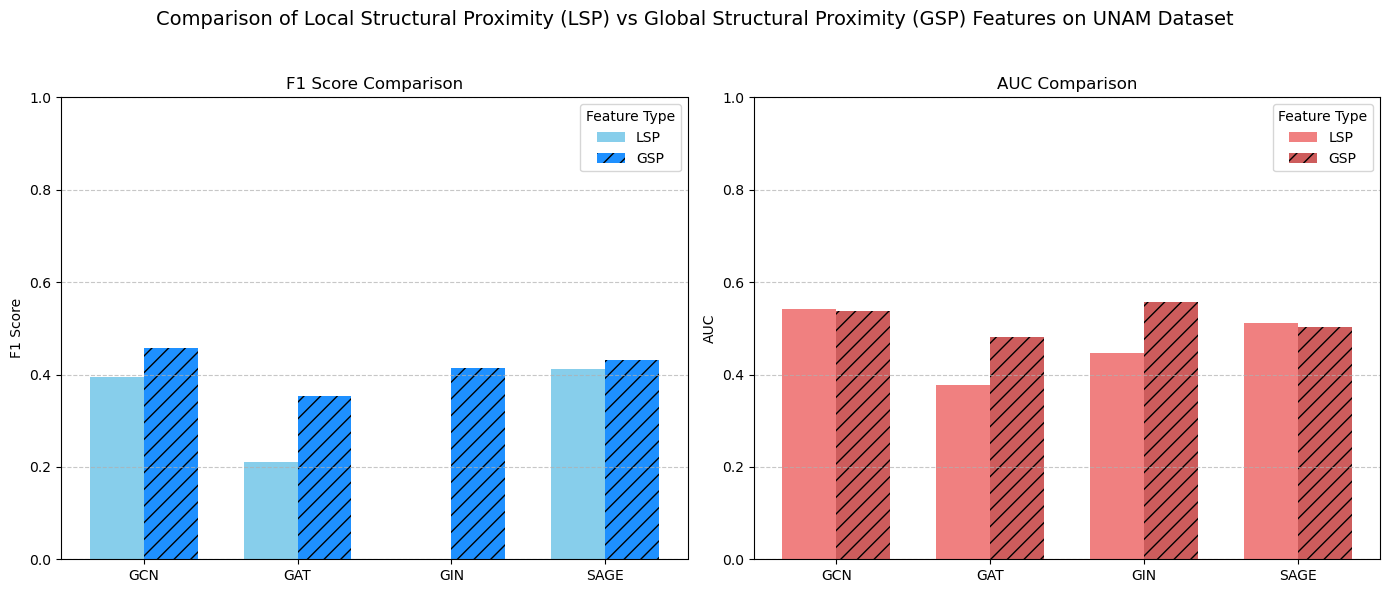

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['GCN','GAT','GIN','SAGE']

# Metric values
F1_LSP = [0.395062, 0.209677, 0.0, 0.412121]
F1_GSP = [0.457143, 0.352941, 0.415094, 0.430939]

AUC_LSP = [0.542288, 0.377705, 0.447335, 0.511128]
AUC_GSP = [0.536756, 0.480149, 0.556393, 0.502913]

x = np.arange(len(models))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

# F1 subplot
ax1.bar(x - width/2, F1_LSP, width, label='LSP', color='skyblue')
ax1.bar(x + width/2, F1_GSP, width, label='GSP', color='dodgerblue', hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0,1)
ax1.set_ylabel('F1 Score')
ax1.set_title('F1 Score Comparison')
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(title='Feature Type')

# AUC subplot
ax2.bar(x - width/2, AUC_LSP, width, label='LSP', color='lightcoral')
ax2.bar(x + width/2, AUC_GSP, width, label='GSP', color='indianred', hatch='//')
ax2.set_xticks(x)
ax2.set_xticklabels(models)
ax2.set_ylim(0,1)
ax2.set_ylabel('AUC')
ax2.set_title('AUC Comparison')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
ax2.legend(title='Feature Type')

plt.suptitle('Comparison of Local Structural Proximity (LSP) vs Global Structural Proximity (GSP) Features on UNAM Dataset', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


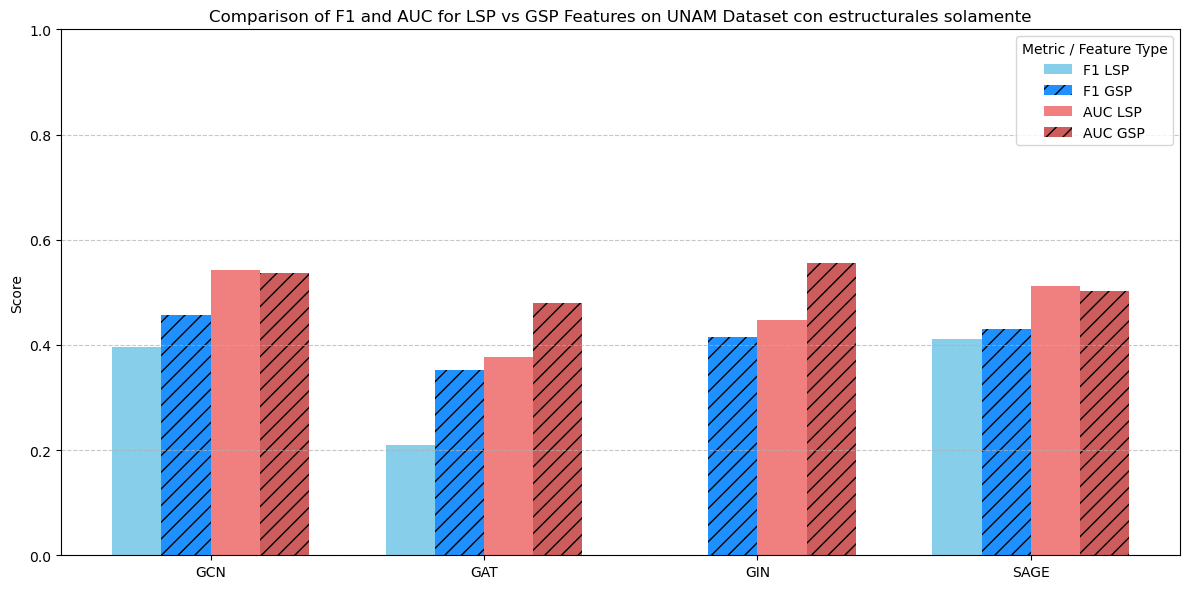

In [7]:
import matplotlib.pyplot as plt
import numpy as np

models = ['GCN','GAT','GIN','SAGE']

F1_LSP = [0.395062, 0.209677, 0.0, 0.412121]
F1_GSP = [0.457143, 0.352941, 0.415094, 0.430939]
AUC_LSP = [0.542288, 0.377705, 0.447335, 0.511128]
AUC_GSP = [0.536756, 0.480149, 0.556393, 0.502913]

x = np.arange(len(models))
width = 0.18  # menor ancho para que entren 4 barras por modelo

fig, ax = plt.subplots(figsize=(12,6))

# Dibujar barras
ax.bar(x - 1.5*width, F1_LSP, width, label='F1 LSP', color='skyblue')
ax.bar(x - 0.5*width, F1_GSP, width, label='F1 GSP', color='dodgerblue', hatch='//')
ax.bar(x + 0.5*width, AUC_LSP, width, label='AUC LSP', color='lightcoral')
ax.bar(x + 1.5*width, AUC_GSP, width, label='AUC GSP', color='indianred', hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparison of F1 and AUC for LSP vs GSP Features on UNAM Dataset con estructurales solamente')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(title='Metric / Feature Type')

plt.tight_layout()
# Guardar en PDF y EPS en la ruta especificada
output_base = r"C:\Users\pilarang\0-ProyAcademicosGrafo-Integrado\2-ServSoc_Implementacion por fechas\LSP-GSP-UNAM-estructurales"
plt.savefig(output_base + ".pdf", format="pdf")
plt.savefig(output_base + ".eps", format="eps")

plt.show()


In [ ]:
P15 FEATURE FSP TRAINING UNAM

In [25]:
#PROGRAMA 15 SOLO FEATURE PROXIMITY CON TRAINING 
#'sum_of_papers', 'sum_of_keywords', 'keywords_match', 'sum_of_areas'
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error,confusion_matrix
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/FP_training_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [ 'sum_of_papers', 'sum_of_keywords', 'keywords_match', 'sum_of_areas']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)

# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['sum_of_papers'],            
                row['sum_of_keywords'], 
                row['keywords_match'],
                row['sum_of_areas']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.5),
        "Precision": precision_score(y_true, y_pred > 0.5, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.5),
        "F1 Score": f1_score(y_true, y_pred > 0.5),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=4,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P15-mejor_modelo_GCN.pth")
print("P15-Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P15-mejor_modelo_GAT.pth")
print("P15-Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P15-mejor_modelo_GIN.pth")
print("P15-Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P15-mejor_modelo_SAGE.pth")
print("P15-Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P15-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P15-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P15-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P15-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 P15-Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P15-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P15-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P15-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P15-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P15-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P15-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble


Best GCN hyperparameters: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Best GCN validation loss: 0.6793361306190491
Best GAT hyperparameters: {'hidden_channels': 25, 'heads': 2, 'dropout_rate': 0.370043381034146, 'learning_rate': 0.007222350846183802, 'weight_decay': 0.0010947660333513005, 'epochs': 56}
Best GAT validation loss: 0.6793992519378662
Mejores parámetros para GCN: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Mejores parámetros para GIN: {'hidden_channels': 84, 'dropout_rate': 0.09546533138986957, 'learning_rate': 0.006718305600877424, 'weight_decay': 0.009175304010220257, 'epochs': 48}
Mejores parámetros para SAGE: {'hidden_channels': 56, 'num_layers': 2, 'dropout_rate': 0.12047387463275988, 'learning_rate': 0.0027366354185616006, 'weight_decay': 0.003808311983396

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:625: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:625: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:625: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000
F1 Score: 0.6667
AUC-ROC: 0.5000
Confusion Matrix:
[[ 0 63]
 [ 0 63]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[63  0]
 [ 0 63]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[63  0]
 [ 0 63]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:654: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:654: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\890399702.py:654: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (SVC):
Accuracy: 0.6587
Precision: 0.7000
Recall: 0.5556
F1 Score: 0.6195
AUC-ROC: 0.6587
Confusion Matrix:
[[48 15]
 [28 35]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9841
Precision: 0.9841
Recall: 0.9841
F1 Score: 0.9841
AUC-ROC: 0.9841
Confusion Matrix:
[[62  1]
 [ 1 62]]



In [ ]:
18 GSP TRAINING UNAM

In [36]:
#PROGRAMA 18  GSP CON TRAINING UNAM
#  'log_secundary_neighbors',  'lenght_short_path',  'community_cn', 'community_ra'
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error,confusion_matrix
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/GSP_training_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [
    'log_secundary_neighbors',  'lenght_short_path',  'community_cn', 'community_ra'
]

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)

# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                 row['log_secundary_neighbors'],
                 row['lenght_short_path'],
                 row['community_cn'],
                 row['community_ra']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=4,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P18-mejor_modelo_GCN.pth")
print("P8-Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P18-mejor_modelo_GAT.pth")
print("P18-Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P18-mejor_modelo_GIN.pth")
print("P18-Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P18-mejor_modelo_SAGE.pth")
print("P8-Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P18-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P18-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P18-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P18-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 P18-Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P18-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P18-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P18-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P18-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P18-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()

# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P18-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble


Best GCN hyperparameters: {'hidden_channels': 88, 'dropout_rate': 0.004252931506361909, 'learning_rate': 0.00907162992674855, 'weight_decay': 0.0004652046349548581, 'epochs': 100}
Best GCN validation loss: 0.6477906703948975
Best GAT hyperparameters: {'hidden_channels': 54, 'heads': 6, 'dropout_rate': 0.23274050859104967, 'learning_rate': 0.006944198504448775, 'weight_decay': 0.0007326369413117291, 'epochs': 56}
Best GAT validation loss: 0.6741610765457153
Mejores parámetros para GCN: {'hidden_channels': 88, 'dropout_rate': 0.004252931506361909, 'learning_rate': 0.00907162992674855, 'weight_decay': 0.0004652046349548581, 'epochs': 100}
Mejores parámetros para GIN: {'hidden_channels': 65, 'dropout_rate': 0.1865106974156902, 'learning_rate': 0.0058776997933080635, 'weight_decay': 0.001009313441190641, 'epochs': 77}
Mejores parámetros para SAGE: {'hidden_channels': 29, 'num_layers': 2, 'dropout_rate': 0.07814354250454825, 'learning_rate': 0.006671505252115448, 'weight_decay': 0.0094286566

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:627: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:627: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:627: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5159
Precision: 0.5179
Recall: 0.4603
F1 Score: 0.4874
AUC-ROC: 0.5159
Confusion Matrix:
[[36 27]
 [34 29]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 0.9524
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
AUC-ROC: 0.9524
Confusion Matrix:
[[63  0]
 [ 6 57]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 0.9524
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
AUC-ROC: 0.9524
Confusion Matrix:
[[63  0]
 [ 6 57]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:656: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:656: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\453570465.py:656: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (SVC):
Accuracy: 0.6825
Precision: 0.7018
Recall: 0.6349
F1 Score: 0.6667
AUC-ROC: 0.6825
Confusion Matrix:
[[46 17]
 [23 40]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9524
Precision: 1.0000
Recall: 0.9048
F1 Score: 0.9500
AUC-ROC: 0.9524
Confusion Matrix:
[[63  0]
 [ 6 57]]



In [ ]:
#respaldo preprocesamiento
SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/FP_training_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [
    'sum_of_papers',  'sum_of_keywords', 'keywords_match', 'sum_of_areas'
]

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)

# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['sum_of_papers'], 
                row['sum_of_keywords'], 
                row['keywords_match'],
                row['sum_of_areas']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)

# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(data_t)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)

In [ ]:
19 FP TRAINING UNAM

In [1]:
#prueba

#PROGRAMA 19 fp training unam
# 'sum_of_papers',  'sum_of_keywords', 'keywords_match', 'sum_of_areas'
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error,confusion_matrix
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


import random
import numpy as np
import torch

# =========================
# 1️⃣ Seeds y reproducibilidad
# =========================
SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# =========================
# 2️⃣ Cargar dataset
# =========================
file_paths = {
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/FP_training_2018-2024.csv",
}

df_train = pd.read_csv(file_paths["train_features"], encoding="latin1")

# =========================
# 3️⃣ Imputar NaN
# =========================
if df_train['lenght_short_path'].isna().sum() > 0:
    df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# =========================
# 4️⃣ Normalización de columnas numéricas
# =========================
numeric_columns = ['sum_of_papers', 'sum_of_keywords', 'keywords_match', 'sum_of_areas', 'lenght_short_path']
scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# =========================
# 5️⃣ Construir grafo de entrenamiento
# =========================
def build_train_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_graph(df_train)

# =========================
# 6️⃣ Asignar características a nodos (promedio si aparece en varias aristas)
# =========================
def add_node_features(G, df):
    node_features = {}
    node_counts = {}
    for _, row in df.iterrows():
        features_row = np.array([row[col] for col in numeric_columns], dtype=float)
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = np.zeros(len(numeric_columns))
                node_counts[node] = 0
            node_features[node] += features_row
            node_counts[node] += 1
    # Promediar los features por nodo
    for node in node_features:
        node_features[node] /= node_counts[node]
    # Asignar a grafo
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# =========================
# 7️⃣ Convertir a PyTorch Geometric
# =========================
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=len(G.nodes))
    data.node_mapping = mapping
    return data

data_t = graph_to_pyg(train_graph)

# =========================
# 8️⃣ Función para ordenar edge_index
# =========================
def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])
    data.edge_index = data.edge_index[:, sorted_indices]
    return data

# =========================
# 9️⃣ Split entrenamiento / validación / test
# =========================
split = RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    is_undirected=True,
    add_negative_train_samples=True,
    neg_sampling_ratio=1.0
)

train_data, val_data, test_data = split(data_t)

# Ordenar para reproducibilidad
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)

# =========================
# 10️⃣ Configuración de Optuna
# =========================
optuna.logging.set_verbosity(optuna.logging.ERROR)

print("Preprocessing completed: data ready for GNN training.")


ModuleNotFoundError: No module named 'torch'

In [41]:
#PROGRAMA 19 fp training unam
# 'sum_of_papers',  'sum_of_keywords', 'keywords_match', 'sum_of_areas'
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error,confusion_matrix
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


import random
import numpy as np
import torch




# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=4,  # Ajusta según tu modelo
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P19-mejor_modelo_GCN.pth")
print("P8-Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P19-mejor_modelo_GAT.pth")
print("P19-Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P19-mejor_modelo_GIN.pth")
print("P19-Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P19-mejor_modelo_SAGE.pth")
print("P19-Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P19-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P19-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P19-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P19-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 P19-Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P19-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P19-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P19-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P19-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P19-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)


## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P19-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble


Best GCN hyperparameters: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Best GCN validation loss: 0.6793361306190491
Best GAT hyperparameters: {'hidden_channels': 25, 'heads': 2, 'dropout_rate': 0.370043381034146, 'learning_rate': 0.007222350846183802, 'weight_decay': 0.0010947660333513005, 'epochs': 56}
Best GAT validation loss: 0.6793992519378662
Mejores parámetros para GCN: {'hidden_channels': 47, 'dropout_rate': 0.41314073299981435, 'learning_rate': 0.008756280184095138, 'weight_decay': 0.001436262330638875, 'epochs': 35}
Mejores parámetros para GIN: {'hidden_channels': 84, 'dropout_rate': 0.09546533138986957, 'learning_rate': 0.006718305600877424, 'weight_decay': 0.009175304010220257, 'epochs': 48}
Mejores parámetros para SAGE: {'hidden_channels': 56, 'num_layers': 2, 'dropout_rate': 0.12047387463275988, 'learning_rate': 0.0027366354185616006, 'weight_decay': 0.003808311983396

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:626: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:626: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:626: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppDa


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000
F1 Score: 0.6667
AUC-ROC: 0.5000
Confusion Matrix:
[[ 0 63]
 [ 0 63]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[63  0]
 [ 0 63]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000
AUC-ROC: 1.0000
Confusion Matrix:
[[63  0]
 [ 0 63]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:655: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:655: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\3830491704.py:655: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppDa


Métricas del modelo meta (SVC):
Accuracy: 0.6587
Precision: 0.7000
Recall: 0.5556
F1 Score: 0.6195
AUC-ROC: 0.6587
Confusion Matrix:
[[48 15]
 [28 35]]

Optimizando XGBoost...

Métricas del modelo meta (XGBoost):
Accuracy: 0.9841
Precision: 0.9841
Recall: 0.9841
F1 Score: 0.9841
AUC-ROC: 0.9841
Confusion Matrix:
[[62  1]
 [ 1 62]]



In [ ]:
CONCLUSION EN GRAFICO SOBRE FP,LSP Y GSP EN TRAINING UNAM


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


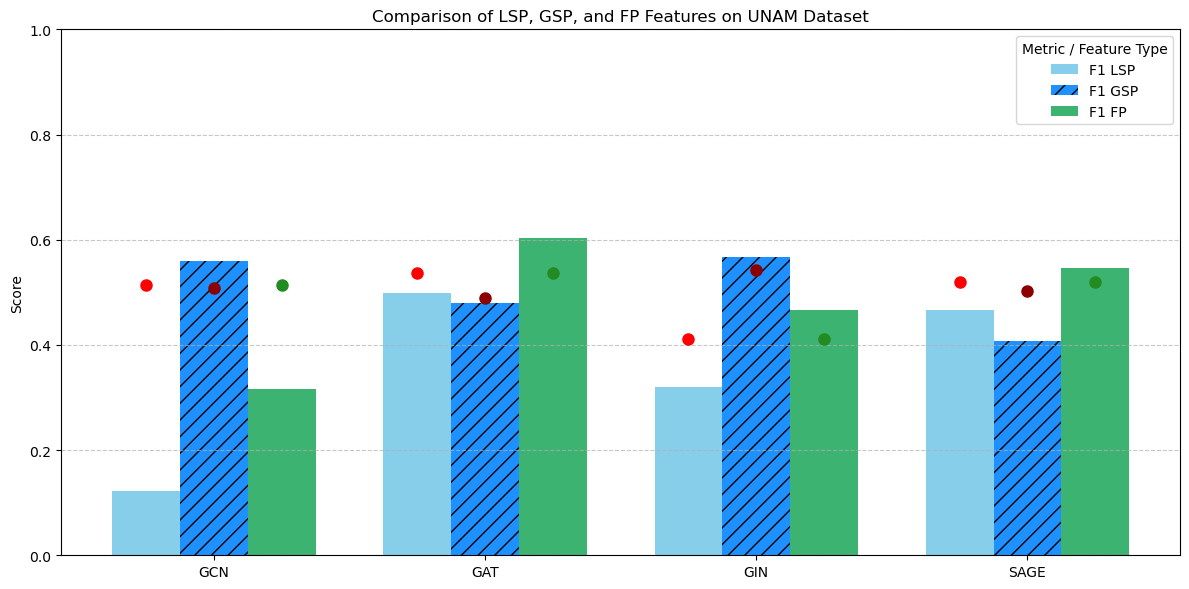

In [6]:
import matplotlib.pyplot as plt
import numpy as np

models = ['GCN','GAT','GIN','SAGE']

# F1 Scores
F1_LSP = [0.123077, 0.497890, 0.320000, 0.466960]
F1_GSP = [0.559211, 0.478764, 0.567273, 0.407407]
F1_FP  = [0.317073, 0.603896, 0.465455, 0.545455]

# AUC Scores
AUC_LSP = [0.514493, 0.537037, 0.411080, 0.519938]
AUC_GSP = [0.508929, 0.489710, 0.542233, 0.502399]
AUC_FP  = [0.514493, 0.537037, 0.411080, 0.519938]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

# Plot F1 bars
ax.bar(x - width, F1_LSP, width, label='F1 LSP', color='skyblue')
ax.bar(x, F1_GSP, width, label='F1 GSP', color='dodgerblue', hatch='//')
ax.bar(x + width, F1_FP, width, label='F1 FP', color='mediumseagreen')

# Overlay AUC as markers
for i in range(len(models)):
    ax.plot(x[i] - width, AUC_LSP[i], marker='o', color='red', markersize=8)
    ax.plot(x[i], AUC_GSP[i], marker='o', color='darkred', markersize=8)
    ax.plot(x[i] + width, AUC_FP[i], marker='o', color='forestgreen', markersize=8)

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Score')
ax.set_ylim(0,1)
ax.set_title('Comparison of LSP, GSP, and FP Features on UNAM Dataset')
ax.legend(title='Metric / Feature Type')

ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
# Guardar en PDF y EPS en la ruta especificada
output_base = r"C:\Users\pilarang\0-ProyAcademicosGrafo-Integrado\2-ServSoc_Implementacion por fechas\LSP-GSP-FP-UNAM-training"
plt.savefig(output_base + ".pdf", format="pdf")
plt.savefig(output_base + ".eps", format="eps")

plt.show()


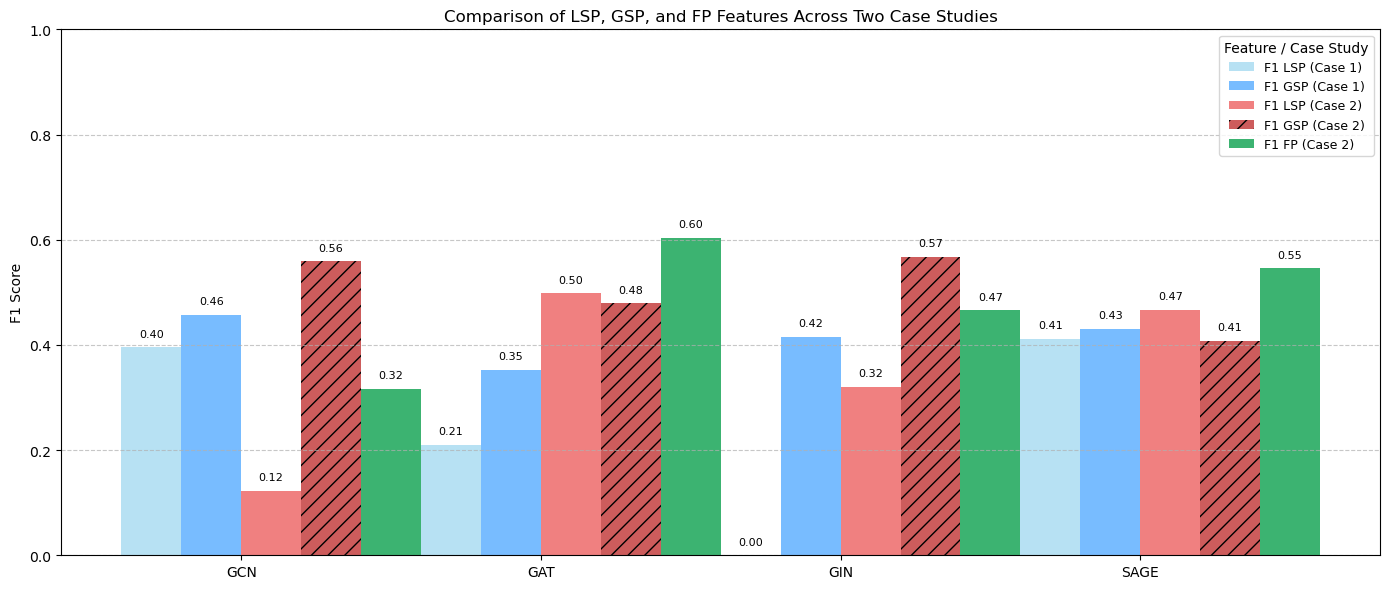

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Modelos
models = ['GCN','GAT','GIN','SAGE']

# Caso 1: P13 LSP y P14 GSP
F1_LSP_case1 = [0.395062, 0.209677, 0.0, 0.412121]
F1_GSP_case1 = [0.457143, 0.352941, 0.415094, 0.430939]

# Caso 2: UNAM P15 LSP, P18 GSP, P19 FP
F1_LSP_case2 = [0.123077, 0.497890, 0.320000, 0.466960]
F1_GSP_case2 = [0.559211, 0.478764, 0.567273, 0.407407]
F1_FP_case2  = [0.317073, 0.603896, 0.465455, 0.545455]

x = np.arange(len(models))
width = 0.2

fig, ax = plt.subplots(figsize=(14,6))

# Caso 1: barras semi-transparentes
ax.bar(x - width*1.5, F1_LSP_case1, width, label='F1 LSP (Case 1)', color='skyblue', alpha=0.6)
ax.bar(x - width*0.5, F1_GSP_case1, width, label='F1 GSP (Case 1)', color='dodgerblue', alpha=0.6)

# Caso 2: barras sólidas
ax.bar(x + width*0.5, F1_LSP_case2, width, label='F1 LSP (Case 2)', color='lightcoral')
ax.bar(x + width*1.5, F1_GSP_case2, width, label='F1 GSP (Case 2)', color='indianred', hatch='//')
# FP
ax.bar(x + width*2.5, F1_FP_case2, width, label='F1 FP (Case 2)', color='mediumseagreen')

# Etiquetas
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('F1 Score')
ax.set_ylim(0,1)
ax.set_title('Comparison of LSP, GSP, and FP Features Across Two Case Studies')
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(fontsize=9, title='Feature / Case Study')

# Añadir valores encima de cada barra
for i in range(len(models)):
    ax.text(x[i]-width*1.5, F1_LSP_case1[i]+0.02, f"{F1_LSP_case1[i]:.2f}", ha='center', fontsize=8)
    ax.text(x[i]-width*0.5, F1_GSP_case1[i]+0.02, f"{F1_GSP_case1[i]:.2f}", ha='center', fontsize=8)
    ax.text(x[i]+width*0.5, F1_LSP_case2[i]+0.02, f"{F1_LSP_case2[i]:.2f}", ha='center', fontsize=8)
    ax.text(x[i]+width*1.5, F1_GSP_case2[i]+0.02, f"{F1_GSP_case2[i]:.2f}", ha='center', fontsize=8)
    ax.text(x[i]+width*2.5, F1_FP_case2[i]+0.02, f"{F1_FP_case2[i]:.2f}", ha='center', fontsize=8)



    # Guardar en PDF y EPS en la ruta especificada
output_base = r"C:\Users\pilarang\0-ProyAcademicosGrafo-Integrado\2-ServSoc_Implementacion por fechas\LSP-GSP-Standford"
plt.savefig(output_base + ".pdf", format="pdf")
plt.savefig(output_base + ".eps", format="eps")


plt.tight_layout()
plt.show()


In [ ]:
16 el siguiente programa checa lsp con datos standford

In [30]:
#PROGRAMA 16 CHECA RENDIMIENTO DE GNN CON LSP DE STANDFORD
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target, coeficiente_agrupamiento_source	coeficiente_agrupamiento_target	centralidad_eigenvector_source	centralidad_eigenvector_target	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target	

#REDUCIENDO ALEATORIEDAD
import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# Cargar datasets
file_paths = {
    #"train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_2018-2024.csv",
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/LSP_estadisticas_autores_1993-2003-final.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  
                     'centralidad_grado_source', 'centralidad_grado_target', 
                     'coeficiente_agrupamiento_source', 'coeficiente_agrupamiento_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['centralidad_grado_source'], 
                row['centralidad_grado_target'],
                row['coeficiente_agrupamiento_source'],
                row['coeficiente_agrupamiento_target']
             ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

train_data = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)


# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(train_data)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.1),
        "Precision": precision_score(y_true, y_pred > 0.1, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.1),
        "F1 Score": f1_score(y_true, y_pred > 0.1),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=4,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=4,  # Número de características de entrada, antes 15 estadisticas, ahora 9
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=4,  # Ajusta según tu modelo al numero de caracteristicas de entrada (estadisticas,no los campos)
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P11-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P16-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P16-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P16-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P16-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P16-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P16-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P16-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P16-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P16-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P16-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P16-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P16-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)

## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P16-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble


Best GCN hyperparameters: {'hidden_channels': 124, 'dropout_rate': 0.3582269908980101, 'learning_rate': 0.008948408611279456, 'weight_decay': 3.2385445395178275e-05, 'epochs': 91}
Best GCN validation loss: 0.5576831698417664
Best GAT hyperparameters: {'hidden_channels': 69, 'heads': 7, 'dropout_rate': 0.2424734548267869, 'learning_rate': 0.00882506031155389, 'weight_decay': 2.6394164103818064e-05, 'epochs': 77}
Best GAT validation loss: 0.5900386571884155
Mejores parámetros para GCN: {'hidden_channels': 124, 'dropout_rate': 0.3582269908980101, 'learning_rate': 0.008948408611279456, 'weight_decay': 3.2385445395178275e-05, 'epochs': 91}
Mejores parámetros para GIN: {'hidden_channels': 84, 'dropout_rate': 0.09546533138986957, 'learning_rate': 0.006718305600877424, 'weight_decay': 0.009175304010220257, 'epochs': 48}
Mejores parámetros para SAGE: {'hidden_channels': 52, 'num_layers': 3, 'dropout_rate': 0.3041132297615244, 'learning_rate': 0.007311719225115481, 'weight_decay': 0.004223362795

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:629: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:629: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:629: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Loc


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5625
Precision: 0.5513
Recall: 0.6710
F1 Score: 0.6053
AUC-ROC: 0.5625
Confusion Matrix:
[[ 8992 10819]
 [ 6517 13294]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 0.7912
Precision: 0.7563
Recall: 0.8593
F1 Score: 0.8045
AUC-ROC: 0.7912
Confusion Matrix:
[[14326  5485]
 [ 2788 17023]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 0.8911
Precision: 0.9183
Recall: 0.8586
F1 Score: 0.8874
AUC-ROC: 0.8911
Confusion Matrix:
[[18297  1514]
 [ 2802 17009]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:658: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:658: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\67910151.py:658: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Loc

KeyboardInterrupt: 

In [ ]:
17 el siguiente programa checa gsp con datos standford

In [ ]:
#PROGRAMA 17 QUE VERIFICA RENDIMIENTO CON GLOBAL STRUCTURAL SIMILARITY GSP STANDFORD 
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
import torch.nn.init as init
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, GINConv
import optuna
import logging
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error
from sklearn.metrics import average_precision_score
from tabulate import tabulate
from torch_geometric.nn import global_mean_pool
import torch.nn.functional as F


#REDUCIENDO ALEATORIEDAD
import random
import numpy as np
import torch

SEED = 41
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True)

# camino_más_corto	pagerank_source	pagerank_target	k_core_number_source	k_core_number_target

# Cargar datasets
file_paths = {
    #"train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/9_estadisticas_autores_2018-2024.csv",
    "train_features": "C:/Users/pilarang/0-ProyAcademicosGrafo-Integrado/2-ServSoc_Implementacion por fechas/GSP_estadisticas_autores_1993-2003-final.csv",
}

df_train = pd.read_csv(file_paths["train_features"])

# Reemplazar NaN en 'lenght_short_path' por la mediana
#df_train['lenght_short_path'] = df_train['lenght_short_path'].fillna(df_train['lenght_short_path'].median())

# Normalizar las columnas numéricas, se hace aqui o en el splitRandom, estan las dos opciones, esta da mejores resultados
numeric_columns = [  'camino_más_corto', 
                     'pagerank_source', 'pagerank_target',
                     'k_core_number_source', 'k_core_number_target']

scaler = MinMaxScaler()
df_train[numeric_columns] = scaler.fit_transform(df_train[numeric_columns])

# Construir grafo de entrenamiento
def build_train_test_graph(df):
    G = nx.Graph()
    for _, row in df.iterrows():
        G.add_edge(row['source'], row['target'], weight=row['connected'])
    return G

train_graph = build_train_test_graph(df_train)
#source	target	connected	camino_mÃ¡s_corto	centralidad_grado_source	centralidad_grado_target	coeficiente_agrupamiento_source	
#coeficiente_agrupamiento_target	pagerank_source	pagerank_target	
#k_core_number_source	k_core_number_target	
# Asignar características a los nodos
def add_node_features(G, df):
    node_features = {}
    for _, row in df.iterrows():
        for node in [row['source'], row['target']]:
            if node not in node_features:
                node_features[node] = []
            node_features[node] = [
                row['camino_más_corto'], 
                row['pagerank_source'],
                row['pagerank_target'],
                row['k_core_number_source'],
                row['k_core_number_target']
            ]
    for node, features in node_features.items():
        if node in G.nodes:
            G.nodes[node]['features'] = features
    return G

train_graph = add_node_features(train_graph, df_train)

# Convertir a PyTorch Geometric
def graph_to_pyg(G):
    mapping = {node: i for i, node in enumerate(G.nodes)}  
    # Si el grafo fue construido con NetworkX y los nodos tienen nombres originales: 
    edge_index = torch.tensor([[mapping[u], mapping[v]] for u, v in G.edges], dtype=torch.long).t().contiguous()
    num_nodes = len(G.nodes)
    node_features = torch.tensor([G.nodes[node]['features'] for node in G.nodes], dtype=torch.float)
    data = Data(x=node_features, edge_index=edge_index, num_nodes=num_nodes)
    data.node_mapping = mapping
    return data

train_data = graph_to_pyg(train_graph)

def sort_edge_index(data):
    sorted_indices = torch.argsort(data.edge_index[1])  # Ordenar por destino
    data.edge_index = data.edge_index[:, sorted_indices]  # Aplicar orden
    return data

# eliminar mensajes de los trials de optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)


# Generar conjuntos de entrenamiento, validación y prueba

# Definir el objeto de división
split = RandomLinkSplit(
    num_val=0.1,  # Fracción de los datos para la validación
    num_test=0.1,  # Fracción de los datos para el test
    is_undirected=True,  # Si es un grafo no dirigido
    add_negative_train_samples=True,  # Agregar enlaces negativos al conjunto de entrenamiento para que no saque predicciones ya existentes
    neg_sampling_ratio=1.0  # Controlar la relación de enlaces negativos por cada enlace positivo (1:1 en este caso) balancea
)


# Realizar el split pero con cambios y transformaciones
train_data, val_data, test_data = split(train_data)
#from torch_geometric.transforms import NormalizeFeatures
#transform = NormalizeFeatures()
#test_data = transform(train_data)

#split = RandomLinkSplit(is_undirected=True)  #version de split original los enlaces existentes pueden salir en las predicciones:erróneo
#train_data, val_data, test_data = split(train_data)

# Ordenar los conjuntos de datos por el modelo SAGE
train_data = sort_edge_index(train_data)
val_data = sort_edge_index(val_data)
test_data = sort_edge_index(test_data)


# Definir modelos
class GCNLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GATLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1, heads=1, dropout=0.0):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

class GINLinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = GINConv(torch.nn.Sequential(torch.nn.Linear(in_channels, hidden_channels), torch.nn.ReLU()))
        self.conv2 = GINConv(torch.nn.Sequential(torch.nn.Linear(hidden_channels, 1)))
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)



class SAGELinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, dropout=0.0):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index)
        return x

    def decode(self, x, edge_label_index):
        return (x[edge_label_index[0]] * x[edge_label_index[1]]).sum(dim=-1)

#evaluacion de modelos
def evaluate_model(model, data):
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():
        predictions = model(data.x, data.edge_index).squeeze()

    y_pred = predictions.detach().cpu().numpy().flatten()

    # Manejar valores NaN en y_pred
    y_pred = np.nan_to_num(y_pred, nan=0.0)  # Reemplazar NaN con 0.0

    # Generar `y_true` con el mismo tamaño que `y_pred`
    y_true = torch.randint(0, 2, (len(y_pred),)).cpu().numpy()

    return {
        "Accuracy": accuracy_score(y_true, y_pred > 0.5),
        "Precision": precision_score(y_true, y_pred > 0.5, zero_division=1),
        "Recall": recall_score(y_true, y_pred > 0.5),
        "F1 Score": f1_score(y_true, y_pred > 0.5),
        "AUC-ROC": roc_auc_score(y_true, y_pred),
        "AUC-PR": average_precision_score(y_true, y_pred),
        "MSE": mean_squared_error(y_true, y_pred)
    }

# Entrenamiento y evaluación

def train_and_evaluate_model(model, train_data, val_data, epochs, criterion, lr, weight_decay):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()

    # Entrenamiento
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        x = model(train_data.x, train_data.edge_index)  # Pasa las features y las aristas
        out = model.decode(x, train_data.edge_label_index).squeeze()  # Decodifica los enlaces
        loss = criterion(out, train_data.edge_label.float())  # Calcula la pérdida
        loss.backward()
        optimizer.step()

    # Evaluación
    model.eval()
    with torch.no_grad():
        x_val = model(val_data.x, val_data.edge_index)
        val_out = model.decode(x_val, val_data.edge_label_index).squeeze()
        val_loss = criterion(val_out, val_data.edge_label.float()).item()  # Calcula la pérdida en validación

    return val_loss


   
# Objetivo para optimización con Optuna
def objective_gcn(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)  
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GCNLinkPredictor(
        in_channels=5,  # Número de características de entrada
        hidden_channels=hidden_channels,
        dropout=dropout_rate,
    )

    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
   # val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)  
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss

def objective_gat(trial):
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    heads = trial.suggest_int("heads", 1, 8)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2) 
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    model = GATLinkPredictor(
        in_channels=5,  # Número de características de entrada
        hidden_channels=hidden_channels,
        heads=heads,
        dropout=dropout_rate
    )
    
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs=epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
    
def objective_gin(trial):
    # Hiperparámetros a optimizar
    hidden_channels = trial.suggest_int("hidden_channels", 16, 128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GIN
    model = GINLinkPredictor(
        in_channels=5,  # Número de características de entrada, antes 15 estadisticas, ahora 9
        hidden_channels=hidden_channels,  # Número de canales ocultos
        dropout=dropout_rate  # Tasa de dropout
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss


def objective_sage(trial):
    # Hiperparámetros para optimización
    hidden_channels = trial.suggest_int("hidden_channels", 16, 64)
    num_layers = trial.suggest_int("num_layers", 2, 4)
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2)
    aggr_method = trial.suggest_categorical("aggr_method", ["mean", "max", "lstm"])
    epochs = trial.suggest_int("epochs", 10, 100)

    # Definir el modelo GraphSAGE
    
    model = SAGELinkPredictor(
        in_channels=5,  # Ajusta según tu modelo al numero de caracteristicas de entrada (estadisticas,no los campos)
        hidden_channels=hidden_channels,
        #num_layers=num_layers,
        #aggr=aggr_method,
        dropout=dropout_rate
    )

    # Optimización
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

      # Llama a la función con todos los argumentos
    criterion = torch.nn.BCEWithLogitsLoss()
    #val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion=criterion)
    val_loss = train_and_evaluate_model(model, train_data, val_data, epochs, criterion, learning_rate, weight_decay)
    return val_loss
           

# Optuna para GCN
#study_gcn = optuna.create_study(direction="minimize")
study_gcn = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gcn.optimize(objective_gcn, n_trials=50)

print("Best GCN hyperparameters:", study_gcn.best_params)
print("Best GCN validation loss:", study_gcn.best_value)

# Optuna para GAT
#study_gat = optuna.create_study(direction="minimize")
study_gat = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gat.optimize(objective_gat, n_trials=50)

print("Best GAT hyperparameters:", study_gat.best_params)
print("Best GAT validation loss:", study_gat.best_value)

# Estudio y optimización para GIN
#study_gin = optuna.create_study(direction="minimize")
study_gin = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_gin.optimize(objective_gin, n_trials=10)

# Estudio y optimización para SAGE
#study_sage = optuna.create_study(direction="minimize")
study_sage = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))

study_sage.optimize(objective_sage, n_trials=10)

# Imprimir los mejores parámetros para cada modelo
print("Mejores parámetros para GCN:", study_gcn.best_params)
print("Mejores parámetros para GIN:", study_gin.best_params)
print("Mejores parámetros para SAGE:", study_sage.best_params)
print("Mejores parámetros para GAT:", study_gat.best_params)


# Entrenamiento y guardado de los modelos

# Entrenar y guardar el modelo GCN
best_params = study_gcn.best_params
gcn_model = GCNLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gcn = torch.optim.Adam(gcn_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

criterion = torch.nn.BCEWithLogitsLoss()

gcn_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gcn.zero_grad()
    x = gcn_model(train_data.x, train_data.edge_index)
    out = gcn_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gcn.step()

torch.save(gcn_model.state_dict(), "P17-mejor_modelo_GCN.pth")
print("Modelo GCN guardado.")

# Entrenamiento y guardado del modelo GAT
best_params = study_gat.best_params
if 'heads' in best_params:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=best_params["heads"], dropout=best_params["dropout_rate"])
else:
    gat_model = GATLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], out_channels=1, heads=1, dropout=best_params["dropout_rate"])

optimizer_gat = torch.optim.Adam(gat_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gat_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gat.zero_grad()
    x = gat_model(train_data.x, train_data.edge_index)
    out = gat_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gat.step()

torch.save(gat_model.state_dict(), "P17-mejor_modelo_GAT.pth")
print("Modelo GAT guardado.")

# Entrenamiento y guardado del modelo GIN
best_params = study_gin.best_params
gin_model = GINLinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout_rate"])
optimizer_gin = torch.optim.Adam(gin_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])

gin_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_gin.zero_grad()
    x = gin_model(train_data.x, train_data.edge_index)
    out = gin_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_gin.step()

torch.save(gin_model.state_dict(), "P17-mejor_modelo_GIN.pth")
print("Modelo GIN guardado.")

# Entrenamiento y guardado del modelo SAGE
#sage_model = SAGELinkPredictor(train_data.x.shape[1], best_params["hidden_channels"], dropout=best_params["dropout"])
best_params = study_sage.best_params
sage_model = SAGELinkPredictor(
    in_channels=train_data.x.shape[1],  
    hidden_channels=best_params["hidden_channels"],  
    #num_layers=best_params["num_layers"],  
    #aggr=best_params["aggr_method"],  
    dropout=best_params["dropout_rate"]  
)

optimizer_sage = torch.optim.Adam(sage_model.parameters(), lr=best_params["learning_rate"], weight_decay=best_params["weight_decay"])
criterion = torch.nn.BCEWithLogitsLoss()
sage_model.train()
for epoch in range(best_params["epochs"]):
    optimizer_sage.zero_grad()
    x = sage_model(train_data.x, train_data.edge_index)
    out = sage_model.decode(x, train_data.edge_label_index).squeeze()
    loss = criterion(out, train_data.edge_label.float())
    loss.backward()
    optimizer_sage.step()

torch.save(sage_model.state_dict(), "P17-mejor_modelo_SAGE.pth")
print("Modelo SAGE guardado.")


# Cargar todos los modelos para evaluación
gcn_model.load_state_dict(torch.load("P17-mejor_modelo_GCN.pth"))
gcn_model.eval()

gat_model.load_state_dict(torch.load("P17-mejor_modelo_GAT.pth"))
gat_model.eval()

gin_model.load_state_dict(torch.load("P17-mejor_modelo_GIN.pth"))
gin_model.eval()

sage_model.load_state_dict(torch.load("P17-mejor_modelo_SAGE.pth"))
sage_model.eval()

# Evaluar todos los modelos
metrics_gcn = evaluate_model(gcn_model, test_data)
metrics_gat = evaluate_model(gat_model, test_data)
metrics_gin = evaluate_model(gin_model, test_data)
metrics_sage = evaluate_model(sage_model, test_data)

# Crear DataFrame para comparar las métricas
df_metrics = pd.DataFrame([metrics_gcn, metrics_gat, metrics_gin, metrics_sage], index=["GCN", "GAT", "GIN", "SAGE"])

# Mostrar las métricas de los cuatro modelos
print("\n📊 Métricas comparativas de GCN, GAT, GIN y SAGE:")
print(df_metrics)
df_metrics.to_csv("P17-metricas_comparativas.csv", index=True)

#predicciones con test_data
reverse_mapping = {v: k for k, v in test_data.node_mapping.items()}
test_pairs = list(zip(test_data.edge_label_index[0].cpu().numpy(), test_data.edge_label_index[1].cpu().numpy()))

# Mostrar las predicciones de los cuatro modelos
if gcn_model is not None:
    with torch.no_grad():
        x_gcn = gcn_model(test_data.x, test_data.edge_index)
        gcn_predictions = gcn_model.decode(x_gcn, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gcn_predictions = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gcn_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gcn_predictions)]
        gcn_edges = sorted(gcn_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GCN:")
        for author1, author2, score in gcn_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gcn_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P17-predicciones_gcn.csv", index=False)

if gat_model is not None:
    with torch.no_grad():
        x_gat = gat_model(test_data.x, test_data.edge_index)
        gat_predictions = gat_model.decode(x_gat, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gat_predictions = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gat_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gat_predictions)]
        gat_edges = sorted(gat_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GAT:")
        for author1, author2, score in gat_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gat_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P17-predicciones_gat.csv", index=False)


if gin_model is not None:
    with torch.no_grad():
        x_gin = gin_model(test_data.x, test_data.edge_index)
        gin_predictions = gin_model.decode(x_gin, test_data.edge_label_index).sigmoid().cpu().numpy()
        #gin_predictions = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        gin_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, gin_predictions)]
        gin_edges = sorted(gin_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones GIN:")
        for author1, author2, score in gin_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(gin_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P17-predicciones_gin.csv", index=False)

#print("Primeras características de nodos:", test_data.x[:5])
#print("Primeras conexiones (edge_index):", test_data.edge_index[:, :5])

if sage_model is not None:
    with torch.no_grad():
        x_sage = sage_model(test_data.x, test_data.edge_index)
        sage_predictions = sage_model.decode(x_sage, test_data.edge_label_index).sigmoid().cpu().numpy()
        #sage_predictions = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
        sage_edges = [(reverse_mapping[u], reverse_mapping[v], score) for (u, v), score in zip(test_pairs, sage_predictions)]
        sage_edges = sorted(sage_edges, key=lambda x: x[2], reverse=True)[:20]
        print("\nPrimeras 20 predicciones SAGE:")
        for author1, author2, score in sage_edges:
            print(f"{author1} - {author2}: {score:.4f}")
        pd.DataFrame(sage_edges, columns=["Autor1", "Autor2", "Score"]).to_csv("P17-predicciones_sage.csv", index=False)

#print("¿GCN y GAT producen las mismas predicciones?", np.allclose(gcn_predictions, gat_predictions))
#print("¿GCN y SAGE producen las mismas predicciones?", np.allclose(gin_predictions, sage_predictions))


print("Configuración GCN:", gcn_model)
print("Configuración GAT:", gat_model)
print("Configuración GIN:", gin_model)
print("Configuración SAGE:", sage_model)

## ensamble de aqui hacia arriba ya no cambiar #
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

#import xgboost as xgb
# Obtener las predicciones de los modelos

true_labels = test_data.edge_label.cpu().numpy()
        
# Verifica la longitud de las etiquetas y las predicciones
#print("Número de etiquetas", len(true_labels))  # Debe ser el mismo tamaño que las predicciones
# Debe ser el mismo tamaño que las etiquetas

predicciones_gcn = gcn_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gcn.shape)
#print("Número de predicciones de gcn",len(predicciones_gcn))  

predicciones_gat = gat_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gat.shape)
#print("Número de predicciones de gat",len(predicciones_gat))  

predicciones_gin = gin_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_gin.shape)
#print("Número de predicciones de gin",len(predicciones_gin))  

predicciones_sage = sage_model.decode(test_data.x, test_data.edge_label_index).sigmoid().cpu().numpy()
print(true_labels.shape, predicciones_sage.shape)
#print("Número de predicciones de sage",len(predicciones_sage))  

# Ya entrenado y obtenido las predicciones de los modelos base (GCN, GAT, GIN, SAGE)
X_stack = np.column_stack((predicciones_gcn, predicciones_gat, predicciones_gin, predicciones_sage))

####  optimizar con OPtuna el modelo ensamble meta_model para regresion logistica


# ----- Función genérica de entrenamiento y evaluación -----
def entrenar_y_evaluar(modelo, nombre_modelo):
    modelo.fit(X_stack, true_labels)
    predicciones = modelo.predict(X_stack)
    
    accuracy = accuracy_score(true_labels, predicciones)
    precision = precision_score(true_labels, predicciones)
    recall = recall_score(true_labels, predicciones)
    f1 = f1_score(true_labels, predicciones)
    roc_auc = roc_auc_score(true_labels, predicciones)
    conf_matrix = confusion_matrix(true_labels, predicciones)
    
    print(f"Métricas del modelo meta ({nombre_modelo}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Predicciones con nombres
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = predicciones[i]
        predicciones_autores.append((author1_name, author2_name, score))
    
    return modelo, predicciones_autores
    
# ----- Modelos Meta -----
# 1. Logistic Regression optimizado con Optuna
def objective_logistic(trial):
    meta_model = LogisticRegression(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        max_iter=trial.suggest_int('max_iter', 100, 1000),
        random_state=SEED
    )
    meta_model.fit(X_stack, true_labels)
    predicciones = meta_model.predict(X_stack)
    return roc_auc_score(true_labels, predicciones)

def objective_random_forest(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 20)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_gb(trial):
    model = GradientBoostingClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        max_depth=trial.suggest_int('max_depth', 3, 10)
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_svc(trial):
    model = SVC(
        C=trial.suggest_loguniform('C', 1e-5, 1e5),
        probability=True
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

def objective_xgb(trial):
    model = XGBClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3),
        use_label_encoder=False,
        eval_metric='logloss'
    )
    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)
    return roc_auc_score(true_labels, preds)

# Diccionario de objetivos
objectives = {
    "LogisticRegression": objective_logistic,
    "RandomForest": objective_random_forest,
    "GradientBoosting": objective_gb,
    "SVC": objective_svc,
    "XGBoost": objective_xgb
}

# Resultados
results = {}

for name, obj in objectives.items():
    print(f"Optimizando {name}...")
    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(obj, n_trials=50)
    best_params = study.best_params

    if name == "LogisticRegression":
        model = LogisticRegression(**best_params)
    elif name == "RandomForest":
        model = RandomForestClassifier(**best_params)
    elif name == "GradientBoosting":
        model = GradientBoostingClassifier(**best_params)
    elif name == "SVC":
        model = SVC(**best_params, probability=True)
    elif name == "XGBoost":
        model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')

    model.fit(X_stack, true_labels)
    preds = model.predict(X_stack)

    # Evaluación
    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)
    roc_auc = roc_auc_score(true_labels, preds)
    conf_matrix = confusion_matrix(true_labels, preds)

    print(f"\nMétricas del modelo meta ({name}):")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-ROC: {roc_auc:.4f}")
    print(f"Confusion Matrix:\n{conf_matrix}\n")

    # Guardar predicciones con nombres de autores en diccionario y en archivo
    predicciones_autores = []
    for i, (author1_idx, author2_idx) in enumerate(test_pairs):
        author1_name = reverse_mapping[author1_idx]
        author2_name = reverse_mapping[author2_idx]
        score = float(preds[i])
        predicciones_autores.append((author1_name, author2_name, score))
    results[name] = predicciones_autores
    df = pd.DataFrame(predicciones_autores, columns=["Autor1", "Autor2", "Score"])
        # Formatear la columna Score a 4 decimales
    df["Score"] = df["Score"].map(lambda x: f"{x:.4f}")
    file_name = f"P17-predicciones_meta-{name.replace(' ', '_').lower()}.csv"
    df.to_csv(file_name, index=False)


###  FIN Optimizar con OPtuna modelo ensamble


Best GCN hyperparameters: {'hidden_channels': 87, 'dropout_rate': 0.3393564211878727, 'learning_rate': 0.009380902895362489, 'weight_decay': 1.1456948725702132e-05, 'epochs': 89}
Best GCN validation loss: 0.5438084006309509
Best GAT hyperparameters: {'hidden_channels': 125, 'heads': 6, 'dropout_rate': 0.01232495700137104, 'learning_rate': 0.004891109102844749, 'weight_decay': 2.6124610079388178e-05, 'epochs': 99}
Best GAT validation loss: 0.5682433247566223
Mejores parámetros para GCN: {'hidden_channels': 87, 'dropout_rate': 0.3393564211878727, 'learning_rate': 0.009380902895362489, 'weight_decay': 1.1456948725702132e-05, 'epochs': 89}
Mejores parámetros para GIN: {'hidden_channels': 25, 'dropout_rate': 0.06311197235320248, 'learning_rate': 0.0032966261469881716, 'weight_decay': 0.006432843651925738, 'epochs': 100}
Mejores parámetros para SAGE: {'hidden_channels': 52, 'num_layers': 3, 'dropout_rate': 0.3041132297615244, 'learning_rate': 0.007311719225115481, 'weight_decay': 0.004223362

C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\998385511.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\998385511.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\998385511.py:633: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),
C:\Users\Dra. Pilar\AppData\


Métricas del modelo meta (LogisticRegression):
Accuracy: 0.5138
Precision: 0.5206
Recall: 0.3490
F1 Score: 0.4179
AUC-ROC: 0.5138
Confusion Matrix:
[[13444  6367]
 [12896  6915]]

Optimizando RandomForest...

Métricas del modelo meta (RandomForest):
Accuracy: 0.8035
Precision: 0.7529
Recall: 0.9035
F1 Score: 0.8214
AUC-ROC: 0.8035
Confusion Matrix:
[[13937  5874]
 [ 1912 17899]]

Optimizando GradientBoosting...

Métricas del modelo meta (GradientBoosting):
Accuracy: 0.8468
Precision: 0.8189
Recall: 0.8904
F1 Score: 0.8532
AUC-ROC: 0.8468
Confusion Matrix:
[[15911  3900]
 [ 2171 17640]]

Optimizando SVC...


C:\Users\Dra. Pilar\AppData\Local\Temp\ipykernel_12624\998385511.py:662: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  C=trial.suggest_loguniform('C', 1e-5, 1e5),


In [ ]:
analisis grafica comparativa programa 16 y 17 LSP vs. GSP con Standford

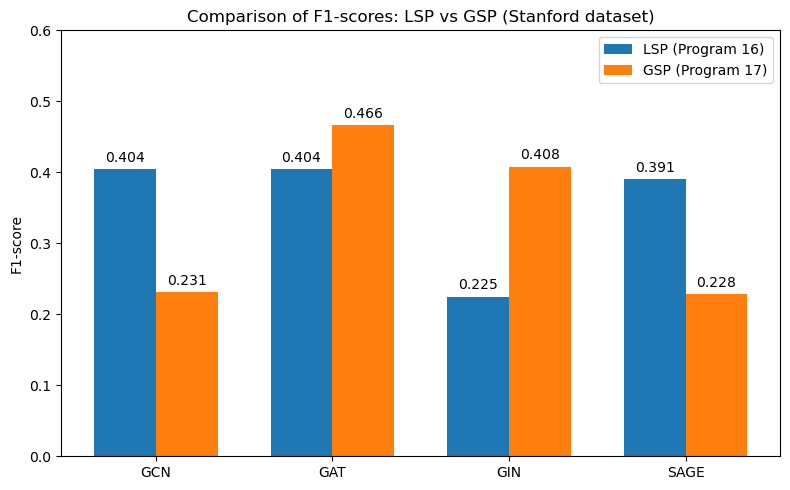

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


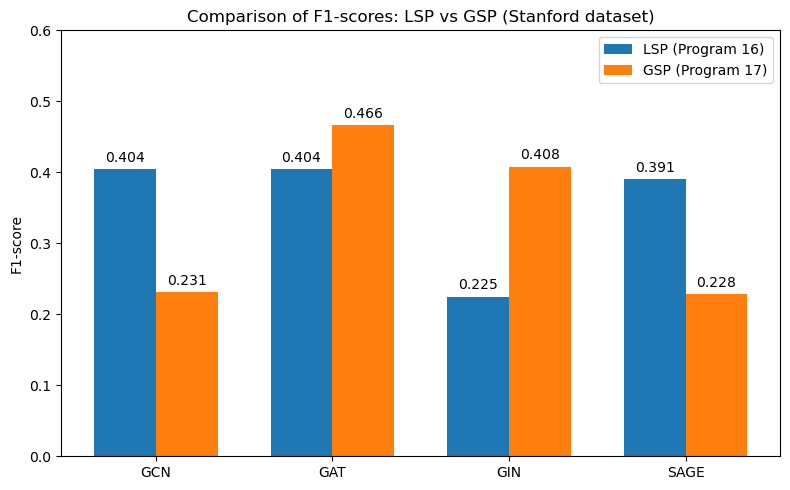

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Models to compare
models = ["GCN", "GAT", "GIN", "SAGE"]

# F1-scores extracted directly from the results of Program 16 (LSP) and Program 17 (GSP)
f1_lsp = [0.404, 0.404, 0.225, 0.391]  # Program 16 (LSP)
f1_gsp = [0.231, 0.466, 0.408, 0.228]  # Program 17 (GSP)

x = np.arange(len(models))  # model positions on the x-axis
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8,5))

# Bars for LSP vs GSP (forzando opacidad con alpha=1)
bars1 = ax.bar(x - width/2, f1_lsp, width, label="LSP (Program 16)", alpha=1)
bars2 = ax.bar(x + width/2, f1_gsp, width, label="GSP (Program 17)", alpha=1)

# Labels and formatting
ax.set_ylabel("F1-score")
ax.set_title("Comparison of F1-scores: LSP vs GSP (Stanford dataset)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 0.6)  # adjust scale for better visualization
ax.legend()

# Annotate values on top of bars
for bars in [bars1, bars2]:
    for b in bars:
        height = b.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(b.get_x() + b.get_width() / 2, height),
                    xytext=(0, 3),  # offset above the bar
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.tight_layout()

# Guardar en PDF y EPS en la ruta especificada
output_base = r"C:\Users\pilarang\0-ProyAcademicosGrafo-Integrado\2-ServSoc_Implementacion por fechas\LSP-GSP-Standford"
plt.savefig(output_base + ".pdf", format="pdf")
plt.savefig(output_base + ".eps", format="eps")

# Mostrar en pantalla
plt.show()


